# Optimizers: SGD to AdamW

## Introduction

The loss $\mathcal{L}_{\mathcal{D}}(\boldsymbol{\Theta})$ can be visualized as a surface in $\mathbb{R}^{|\boldsymbol{\Theta}| + 1}$ where $\mathbb{R}^{|\boldsymbol{\Theta}|}$ is the **parameter space** while the loss value determines the elevation. **Gradient Descent** (GD) finds the minimum of this surface by locally moving in the direction of greatest decrease in loss. The effective step-size in GD depends on (1) the **learning rate**, and (2) the **gradient magnitude**. Tuning the learning rate is non-trivial: too large and the updates oscillate or diverges; too small and it stalls indefinitely in plateaus.

This notebook builds toward **AdamW** [@adamw], the optimizer used in practice for training language models, by deriving each of its components from scratch:

| Topic | Description |
|---|---|
| **GD** | The baseline and its failure modes on ill-conditioned surfaces |
| **Momentum** | Exponential averaging of the gradient to damp oscillations |
| **RMSProp** | Per-parameter adaptive step sizes to handle gradient scale variation |
| **Adam** [@adam] | Momentum + adaptive scaling, with a rigorous derivation of bias correction |
| **AdamW** [@adamw] | Decoupling weight decay from gradient adaptation |
| **SGD** | Making gradient descent tractable at scale with mini-batches |
| **Batch size** | What gradient noise controls, and why bigger $\neq$ better |
| **Learning rate** | Finding and scheduling the most critical hyperparameter |


In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import numpy as np

import matplotlib.pyplot as plt
from matplotlib_inline import backend_inline

RANDOM_SEED = 0
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

def set_plot_params(
    rcparams={
        "font.size": 7,
        "font.family": "monospace",
        "lines.linewidth": 1.0,
        "figure.dpi": 150,
        "figure.figsize": (5, 3),
    },
    plot_format="retina"
):
    plt.rcParams.update(rcparams)
    backend_inline.set_matplotlib_formats(plot_format)

set_plot_params()

### Optimizer template

To experiment with GD algorithms, we define a base class with the standard interface: `zero_grad`, `step`, and `update_param`. The only method that changes between algorithms is `update_param` which encodes the update rule. The optimizer is now **stateful**: it stores momentum vectors, second-moment estimates, etc., as dictionaries keyed by parameter tensor.


In [2]:
class OptimizerBase:
    def __init__(self, params: list, lr: float):
        self.params = params
        self.lr = lr

    def zero_grad(self):
        for p in self.params:
            if p.grad is None:
                continue
            p.grad.detach_()
            p.grad.zero_()

    @torch.no_grad()
    def step(self):
        for p in self.params:
            if p.grad is None:
                continue
            self.update_param(p)

    def update_param(self, p):
        raise NotImplementedError


In [3]:
class GD(OptimizerBase):
    def update_param(self, p):
        p += -self.lr * p.grad


### Pathological loss

We evaluate optimizer behavior on the following [synthetic loss surface](https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/tutorial4/Optimization_and_Initialization.html). The surface is symmetric with a central ravine bordered by steep cliffs and flat plateaus — it is specifically designed to stress-test gradient-based optimization:


In [4]:
#| label: pathological_loss
def pathological_loss(x, y):
    l1 = torch.tanh(x) ** 2 + 0.01 * torch.abs(y)
    l2 = 3 * torch.sigmoid(y)
    return l1 + l2


In [5]:
def pathological_loss_2(x, y):
    """Banana-shaped valley (Rosenbrock variant). Minimum at (1, 1)."""
    return torch.log1p((1 - x) ** 2 + 10 * (y - x ** 2) ** 2)


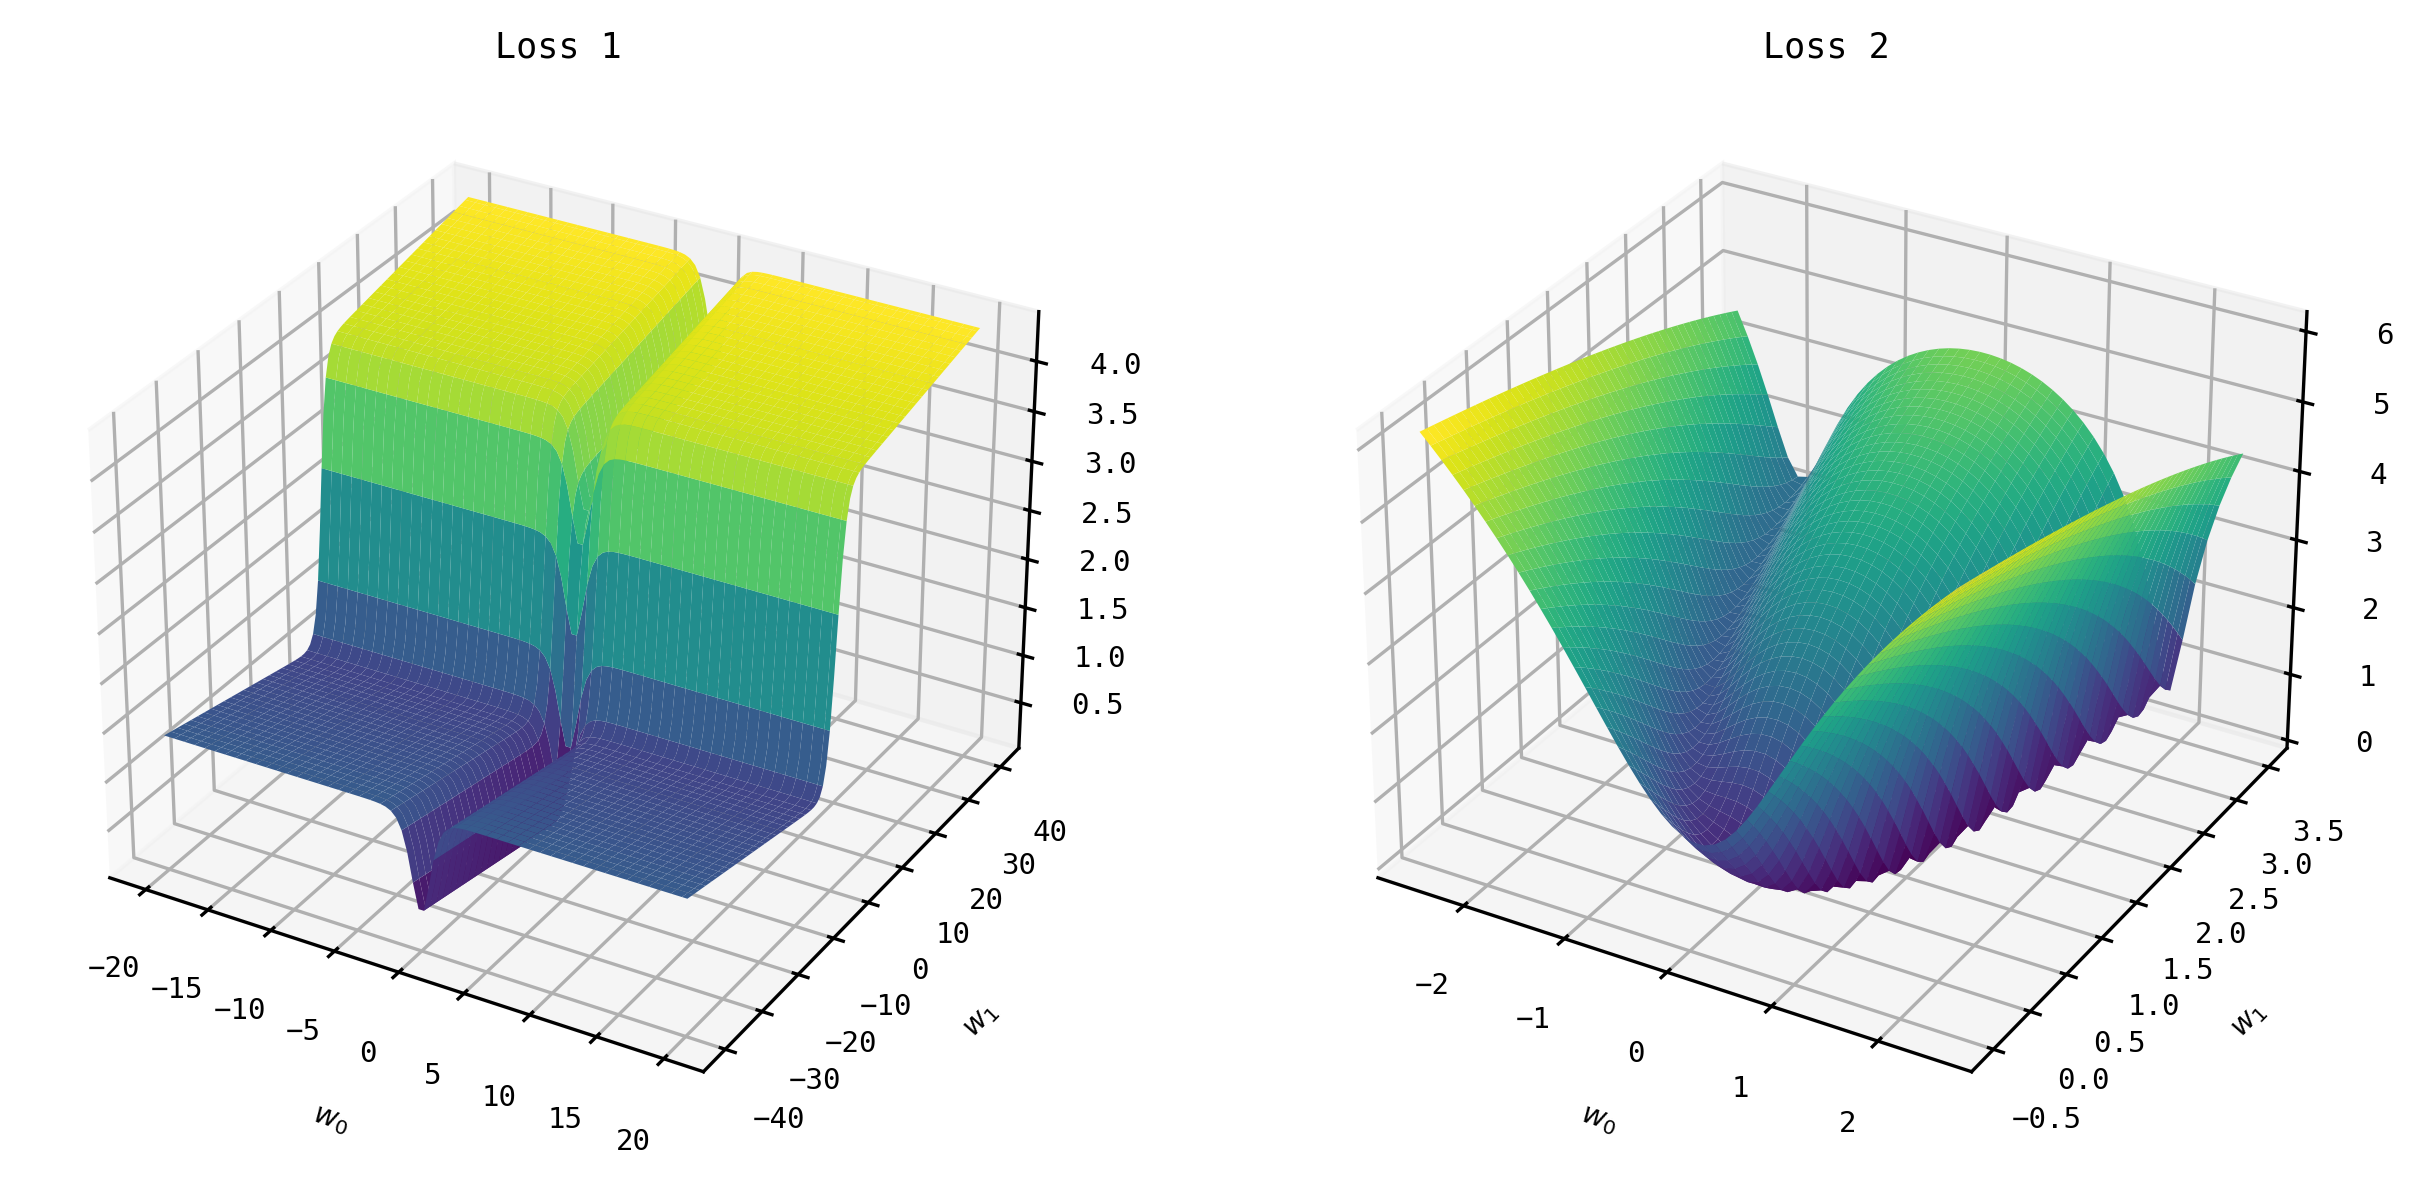

In [6]:
from mpl_toolkits.mplot3d import Axes3D


def plot_surface(ax, f, title="", x_min=-5, x_max=5, y_min=-5, y_max=5, N=50):
    x = np.linspace(x_min, x_max, N)
    y = np.linspace(y_min, y_max, N)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros_like(X)
    for i in range(N):
        for j in range(N):
            Z[i, j] = f(torch.tensor(X[i, j]), torch.tensor(Y[i, j]))
    ax.plot_surface(X, Y, Z, cmap="viridis")
    ax.set_xlabel("$w_0$")
    ax.set_ylabel("$w_1$")
    ax.set_title(title)


def plot_contourf(ax, f, w_hist, color, title="", levels=20,
                  x_min=-5, x_max=5, y_min=-5, y_max=5, N=50, **kw):
    x = np.linspace(x_min, x_max, N)
    y = np.linspace(y_min, y_max, N)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros_like(X)
    for i in range(N):
        for j in range(N):
            Z[i, j] = f(torch.tensor(X[i, j]), torch.tensor(Y[i, j]))
    for t in range(1, len(w_hist)):
        ax.plot([w_hist[t-1][0], w_hist[t][0]],
                [w_hist[t-1][1], w_hist[t][1]], color=color)
    ax.contourf(X, Y, Z, levels=levels, cmap="viridis")
    ax.scatter(w_hist[:, 0], w_hist[:, 1],
               marker="o", s=5, facecolors=color, color=color, **kw)
    ax.set_title(title)
    ax.set_xlabel("$w_0$")
    ax.set_ylabel("$w_1$")


def train_curve(optim_class, optim_params, w_init=[5.0, 5.0],
                loss_fn=pathological_loss, num_steps=100, lr_schedule=None):
    w_init = torch.tensor(w_init).float()
    w = nn.Parameter(w_init, requires_grad=True)
    optim = optim_class([w], **optim_params)
    points = [torch.tensor([w[0], w[1], loss_fn(w[0], w[1])])]
    for step in range(num_steps):
        optim.zero_grad()
        loss = loss_fn(w[0], w[1])
        loss.backward()
        optim.step()
        if lr_schedule is not None:
            lr_schedule(optim, step)
        with torch.no_grad():
            z = loss.unsqueeze(dim=0)
            points.append(torch.cat([w.data, z]))
    return torch.stack(points, dim=0).numpy()


def plot_gd_steps(ax, optim, optim_params, label_map={},
                  w_init=[-2.5, 2.5], num_steps=300, lr_schedule=None,
                  loss_fn=None, x_min=-10, x_max=10, y_min=-15, y_max=10, **plot_kw):
    if loss_fn is None:
        loss_fn = pathological_loss
    label = (optim.__name__ + "("
             + ", ".join(f"{label_map.get(k, k)}={v}"
                         for k, v in optim_params.items())
             + ")")
    path = train_curve(optim, optim_params, w_init=w_init,
                       loss_fn=loss_fn, num_steps=num_steps, lr_schedule=lr_schedule)
    plot_contourf(ax[0], f=loss_fn, w_hist=path,
                  x_min=x_min, x_max=x_max, y_min=y_min, y_max=y_max,
                  label=label, zorder=2, **plot_kw)
    ax[1].plot(np.array(path)[:, 2],
               label=label, color=plot_kw.get("color"), zorder=plot_kw.get("zorder", 1))
    ax[1].set_xlabel("steps")
    ax[1].set_ylabel("loss")
    ax[1].grid(linestyle="dotted", alpha=0.8)
    return path


# Quick sanity check: 3-D surfaces
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(121, projection="3d")
ax2 = fig.add_subplot(122, projection="3d")
plot_surface(ax1, pathological_loss, N=100,
             x_min=-20, x_max=20, y_min=-40, y_max=40,
             title="Loss 1")
plot_surface(ax2, pathological_loss_2, N=50,
             x_min=-2.5, x_max=2.5, y_min=-0.5, y_max=3.5,
             title="Loss 2")


## 1. Gradient Descent

The update rule for gradient descent is:

$$\boldsymbol{\Theta}^{t+1} = \boldsymbol{\Theta}^{t} - \eta \, \nabla_{\boldsymbol{\Theta}}\, \mathcal{L}(\boldsymbol{\Theta}^{t})$$

The step-size is $\eta \lVert \nabla_{\boldsymbol{\Theta}} \mathcal{L} \rVert$ — a product of the learning rate and the gradient magnitude. Two failure modes are visible on the pathological surface below.


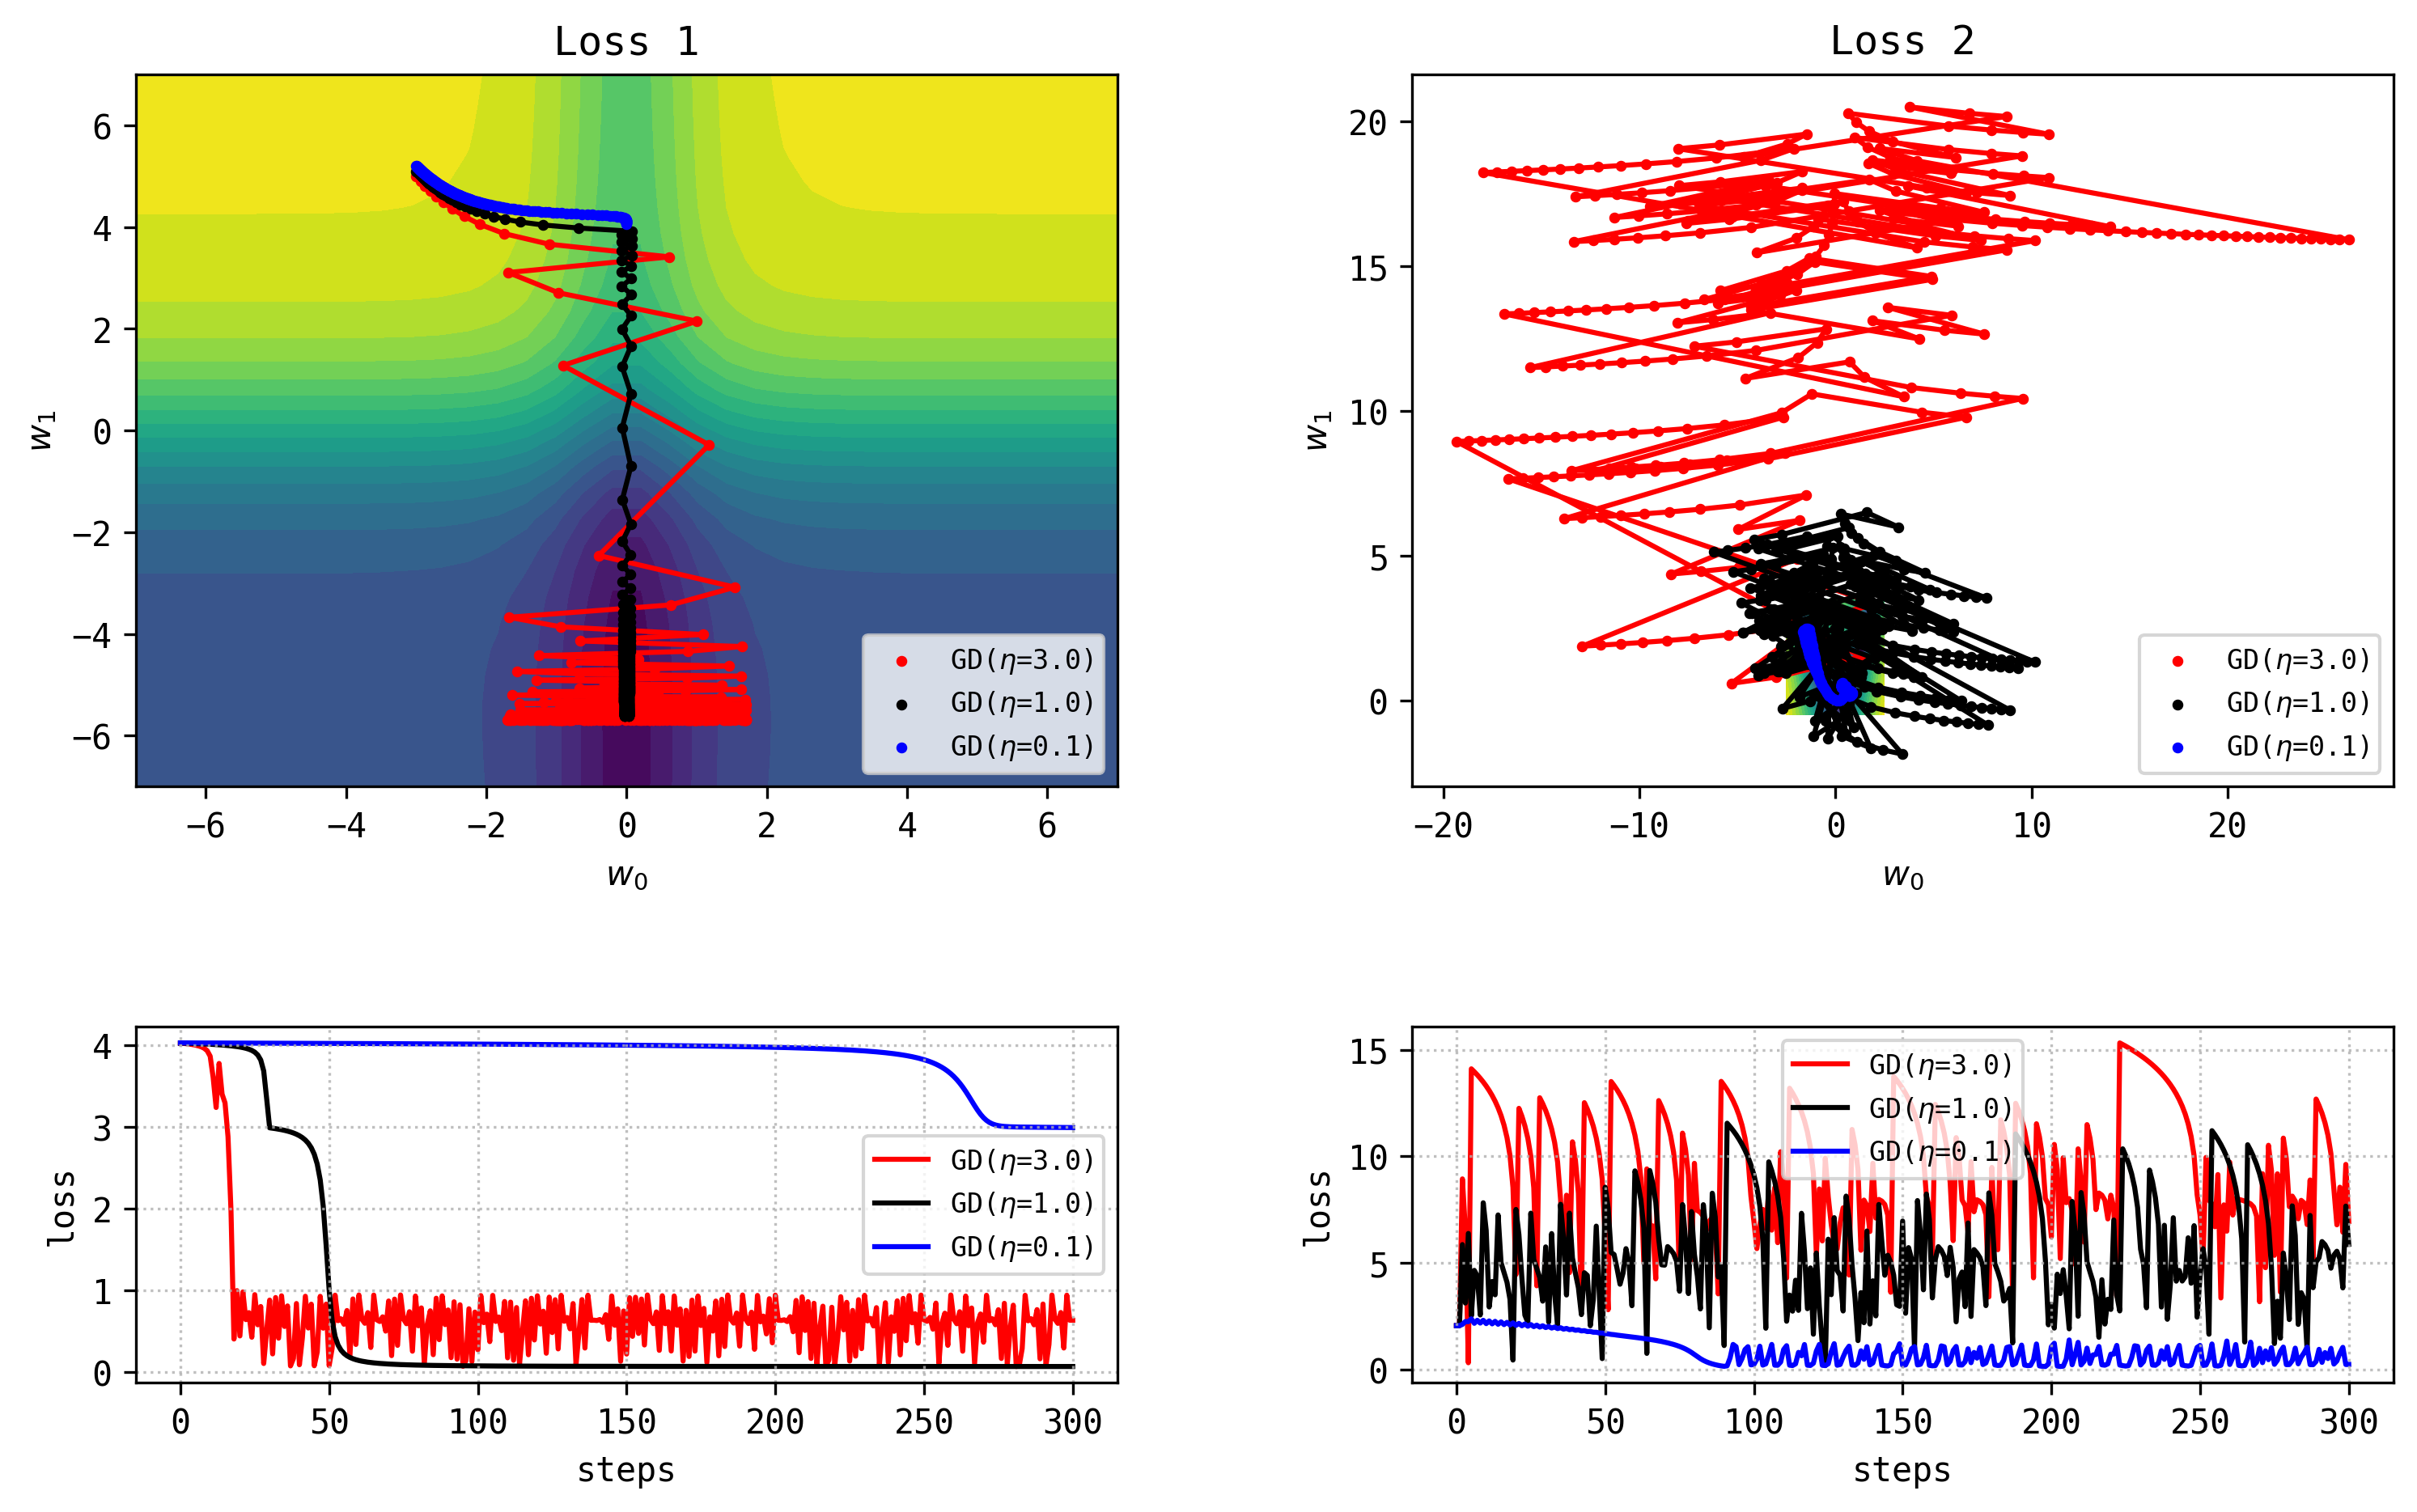

In [7]:
set_plot_params({"font.size": 10, "lines.linewidth": 1.5})
lmap = {"lr": r"$\eta$"}

fig = plt.figure(figsize=(12, 7))
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1], hspace=0.45, wspace=0.3)
ax_tr1 = fig.add_subplot(gs[0, 0])
ax_tr2 = fig.add_subplot(gs[0, 1])
ax_lc1 = fig.add_subplot(gs[1, 0])
ax_lc2 = fig.add_subplot(gs[1, 1])

# Loss 1 — tanh/sigmoid surface
plot_gd_steps([ax_tr1, ax_lc1], GD, {"lr": 3.0}, w_init=[-3.0, 5.0], label_map=lmap, color="red")
plot_gd_steps([ax_tr1, ax_lc1], GD, {"lr": 1.0}, w_init=[-3.0, 5.1], label_map=lmap, color="black")
plot_gd_steps([ax_tr1, ax_lc1], GD, {"lr": 0.1}, w_init=[-3.0, 5.2], label_map=lmap, color="blue")
ax_tr1.set_xlim(-7, 7); ax_tr1.set_ylim(-7, 7)
ax_tr1.set_title("Loss 1"); ax_tr1.legend(loc="lower right", fontsize=8)
ax_lc1.legend(fontsize=8)

# Loss 2 — Rosenbrock surface
plot_gd_steps([ax_tr2, ax_lc2], GD, {"lr": 3.0}, w_init=[-1.5, 2.5], label_map=lmap, color="red",
              loss_fn=pathological_loss_2, x_min=-2.5, x_max=2.5, y_min=-0.5, y_max=3.5)
plot_gd_steps([ax_tr2, ax_lc2], GD, {"lr": 1.0}, w_init=[-1.5, 2.5], label_map=lmap, color="black",
              loss_fn=pathological_loss_2, x_min=-2.5, x_max=2.5, y_min=-0.5, y_max=3.5)
plot_gd_steps([ax_tr2, ax_lc2], GD, {"lr": 0.1}, w_init=[-1.5, 2.5], label_map=lmap, color="blue",
              loss_fn=pathological_loss_2, x_min=-2.5, x_max=2.5, y_min=-0.5, y_max=3.5)
ax_tr2.set_title("Loss 2"); ax_tr2.legend(loc="lower right", fontsize=8)
ax_lc2.legend(fontsize=8)

fig.tight_layout()


^**Two failure modes.** High LR ($\eta=3.0$) oscillates across the ravine: the gradient in the steep $w_1$ direction dominates and the step overshoots. Low LR ($\eta=0.1$) gets trapped in the plateau: the gradient is too small to escape. A moderate $\eta=1.0$ converges, but the optimal value depends on the initialization, making reproducibility fragile.


## 2. The Loss Surface

For convex functions, gradient descent has strong convergence guarantees. Neural network loss surfaces are generally nonconvex. Clever dimensionality reduction allows visualization despite millions of parameters (@fig-02-visualizing-loss from [@visualizing_loss]). Three types of critical points (where $\nabla \mathcal{L} = 0$) are relevant:

![**The loss landscape.** ResNet-56 without (left) and with (right) skip connections. Skip connections dramatically smooth the surface, making optimization easier. **Source:** [@visualizing_loss]](./img/02-visualizing-loss.png){#fig-02-visualizing-loss fig-align="center" width=80%}

![**Three types of critical points** — all difficult for vanilla GD. [Source](https://cs182sp21.github.io/static/slides/lec-4.pdf)](./img/02-optima-type.png){#fig-02-optima-type fig-align="center" width=100%}

### Local minima

Local minima are less of a problem at large scale than intuition suggests. As the number of parameters grows, local minima tend to be increasingly equivalent in value (@fig-02-local-minima).

![**Mean test loss (among many random restarts) shifts toward lower values with decreasing variance as network size grows.** **Source:** [@pmlr-v38-choromanska15]](./img/02-local-minima.png){#fig-02-local-minima fig-align="center" width=80%}

### Plateaus

Plateaus are regions of small gradient — the optimizer barely moves. Large learning rate helps escape; small learning rate gets stuck:


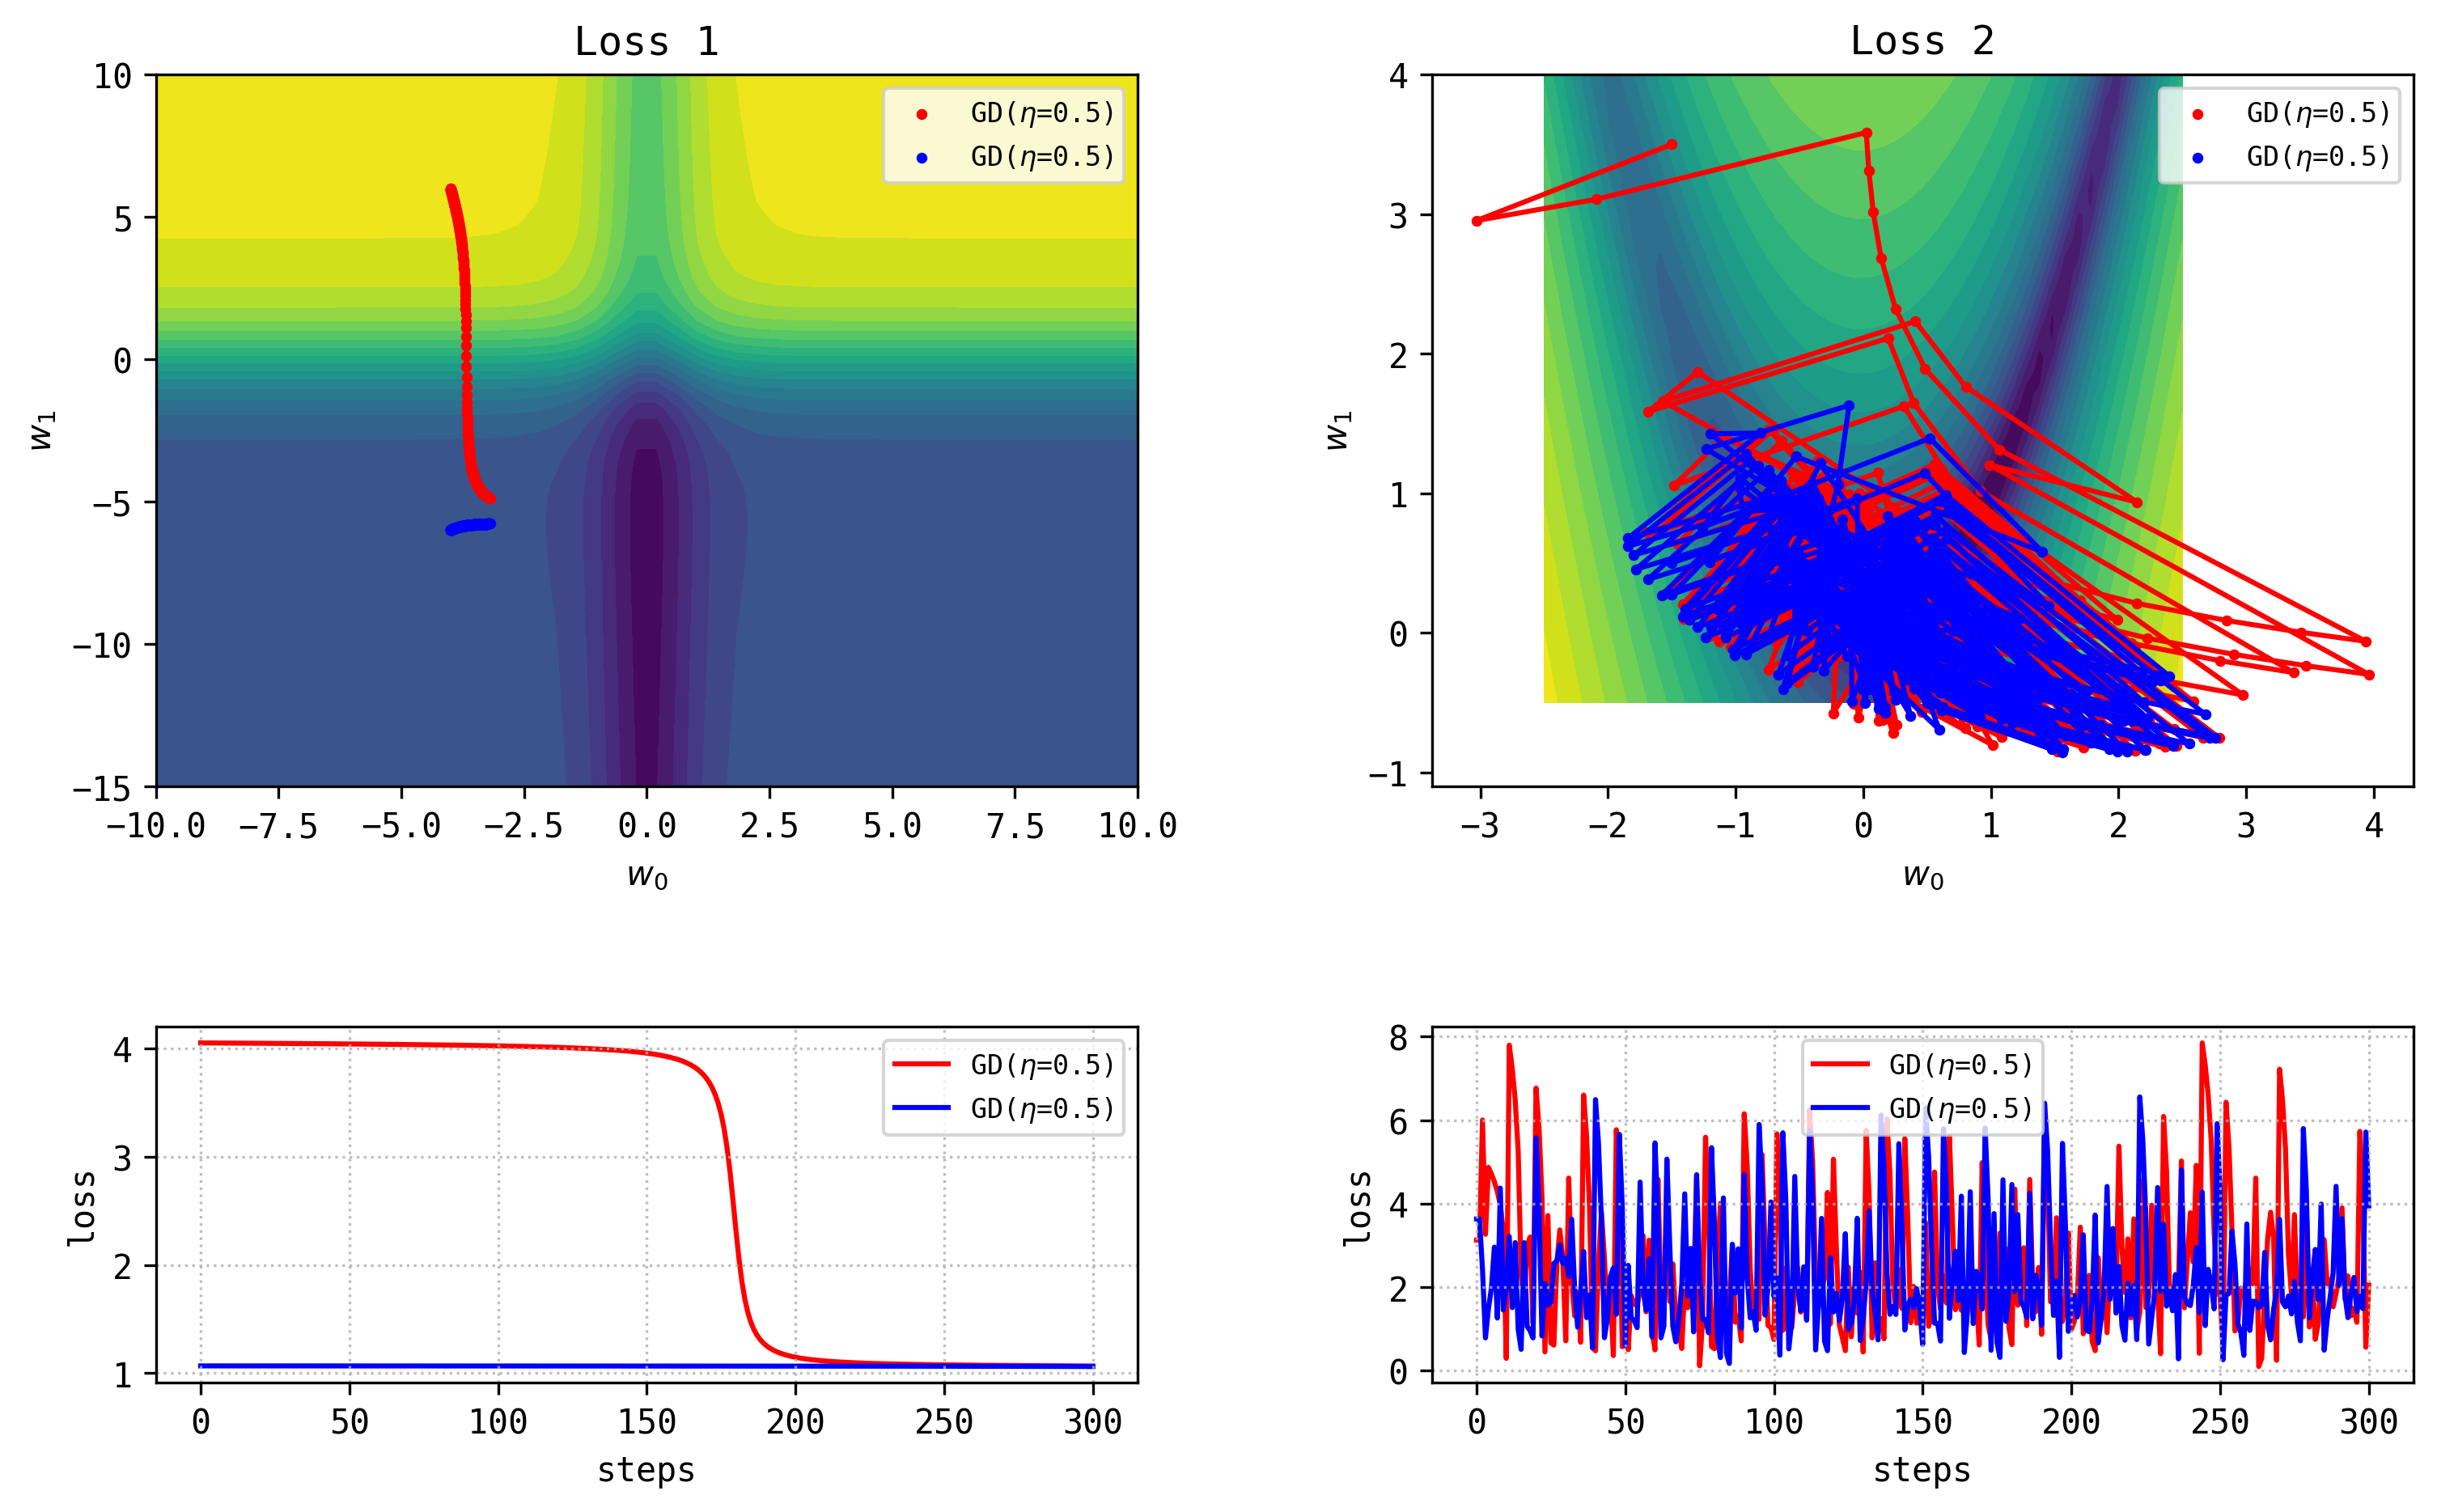

In [8]:
fig = plt.figure(figsize=(12, 7))
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1], hspace=0.45, wspace=0.3)
ax_tr1 = fig.add_subplot(gs[0, 0])
ax_tr2 = fig.add_subplot(gs[0, 1])
ax_lc1 = fig.add_subplot(gs[1, 0])
ax_lc2 = fig.add_subplot(gs[1, 1])

# Loss 1 — tanh/sigmoid surface
plot_gd_steps([ax_tr1, ax_lc1], GD, {"lr": 0.5}, w_init=[-4.0,  6.0],
              label_map={"lr": r"$\eta$"}, color="red")
plot_gd_steps([ax_tr1, ax_lc1], GD, {"lr": 0.5}, w_init=[-4.0, -6.0],
              label_map={"lr": r"$\eta$"}, color="blue")
ax_tr1.set_title("Loss 1"); ax_tr1.legend(fontsize=8)
ax_lc1.legend(fontsize=8)

# Loss 2 — Rosenbrock surface; start above valley vs. below valley
plot_gd_steps([ax_tr2, ax_lc2], GD, {"lr": 0.5}, w_init=[-1.5, 3.5],
              label_map={"lr": r"$\eta$"}, color="red",
              loss_fn=pathological_loss_2, x_min=-2.5, x_max=2.5, y_min=-0.5, y_max=4.0)
plot_gd_steps([ax_tr2, ax_lc2], GD, {"lr": 0.5}, w_init=[-1.5, 0.5],
              label_map={"lr": r"$\eta$"}, color="blue",
              loss_fn=pathological_loss_2, x_min=-2.5, x_max=2.5, y_min=-0.5, y_max=4.0)
ax_tr2.set_title("Loss 2"); ax_tr2.legend(fontsize=8)
ax_lc2.legend(fontsize=8)

fig.tight_layout()


^**Plateau trap.** Starting in the flat region (blue) the optimizer stalls; starting below the plateau (red) it descends efficiently. Because neither a purely large nor purely small LR works, we need a mechanism that adapts the step size dynamically.

### Saddle points

Saddle points are critical points that are local minima in some directions but local maxima in others. Neural networks have enormous symmetry, producing exponentially many local minima which are connected by paths through saddle points (@fig-02-connected-minima). Saddle points are slow to escape because they are surrounded by high-loss plateaus [@dauphin2014].

![**Paths between two minima produce a saddle point.** [Source](https://www.offconvex.org/2016/03/22/saddlepoints/)](./img/02-connected-minima.png){#fig-02-connected-minima fig-align="center" width=60%}

The Hessian $\mathbf{H}$ at any critical point is symmetric (Schwarz's theorem) and therefore has real eigenvalues. The local curvature is classified by the sign of these eigenvalues:

- **All positive**: local minimum ($\mathbf{H}$ positive-definite)
- **All negative**: local maximum
- **Mixed signs**: saddle point

For networks with hundreds of millions of parameters, having all eigenvalues of the same sign is extremely rare, so **most critical points are saddle points**, not local minima.


## 3. Momentum

The intuition behind **momentum**: when successive gradient steps consistently point in the same direction, we should accelerate; when they alternate sign (oscillation), we should dampen. Exponential averaging achieves both with a single parameter $\beta$:

$$
\begin{aligned}
\mathbf{m}^t &= \beta \, \mathbf{m}^{t-1} + (1 - \beta) \, \nabla_{\boldsymbol{\Theta}}\, \mathcal{L}(\boldsymbol{\Theta}^{t}) \\
\boldsymbol{\Theta}^{t+1} &= \boldsymbol{\Theta}^{t} - \eta \, \mathbf{m}^{t}
\end{aligned}
$$

Setting $\beta = 0$ recovers plain GD. The optimizer is now **stateful**: $\mathbf{m}^0 = \boldsymbol{0}$.


In [9]:
class GDMom(OptimizerBase):
    def __init__(self, params, lr, momentum=0.0):
        super().__init__(params, lr)
        self.beta = momentum
        self.m = {id(p): torch.zeros_like(p.data) for p in self.params}

    def update_param(self, p):
        self.m[id(p)] = self.beta * self.m[id(p)] + (1 - self.beta) * p.grad
        p += -self.lr * self.m[id(p)]


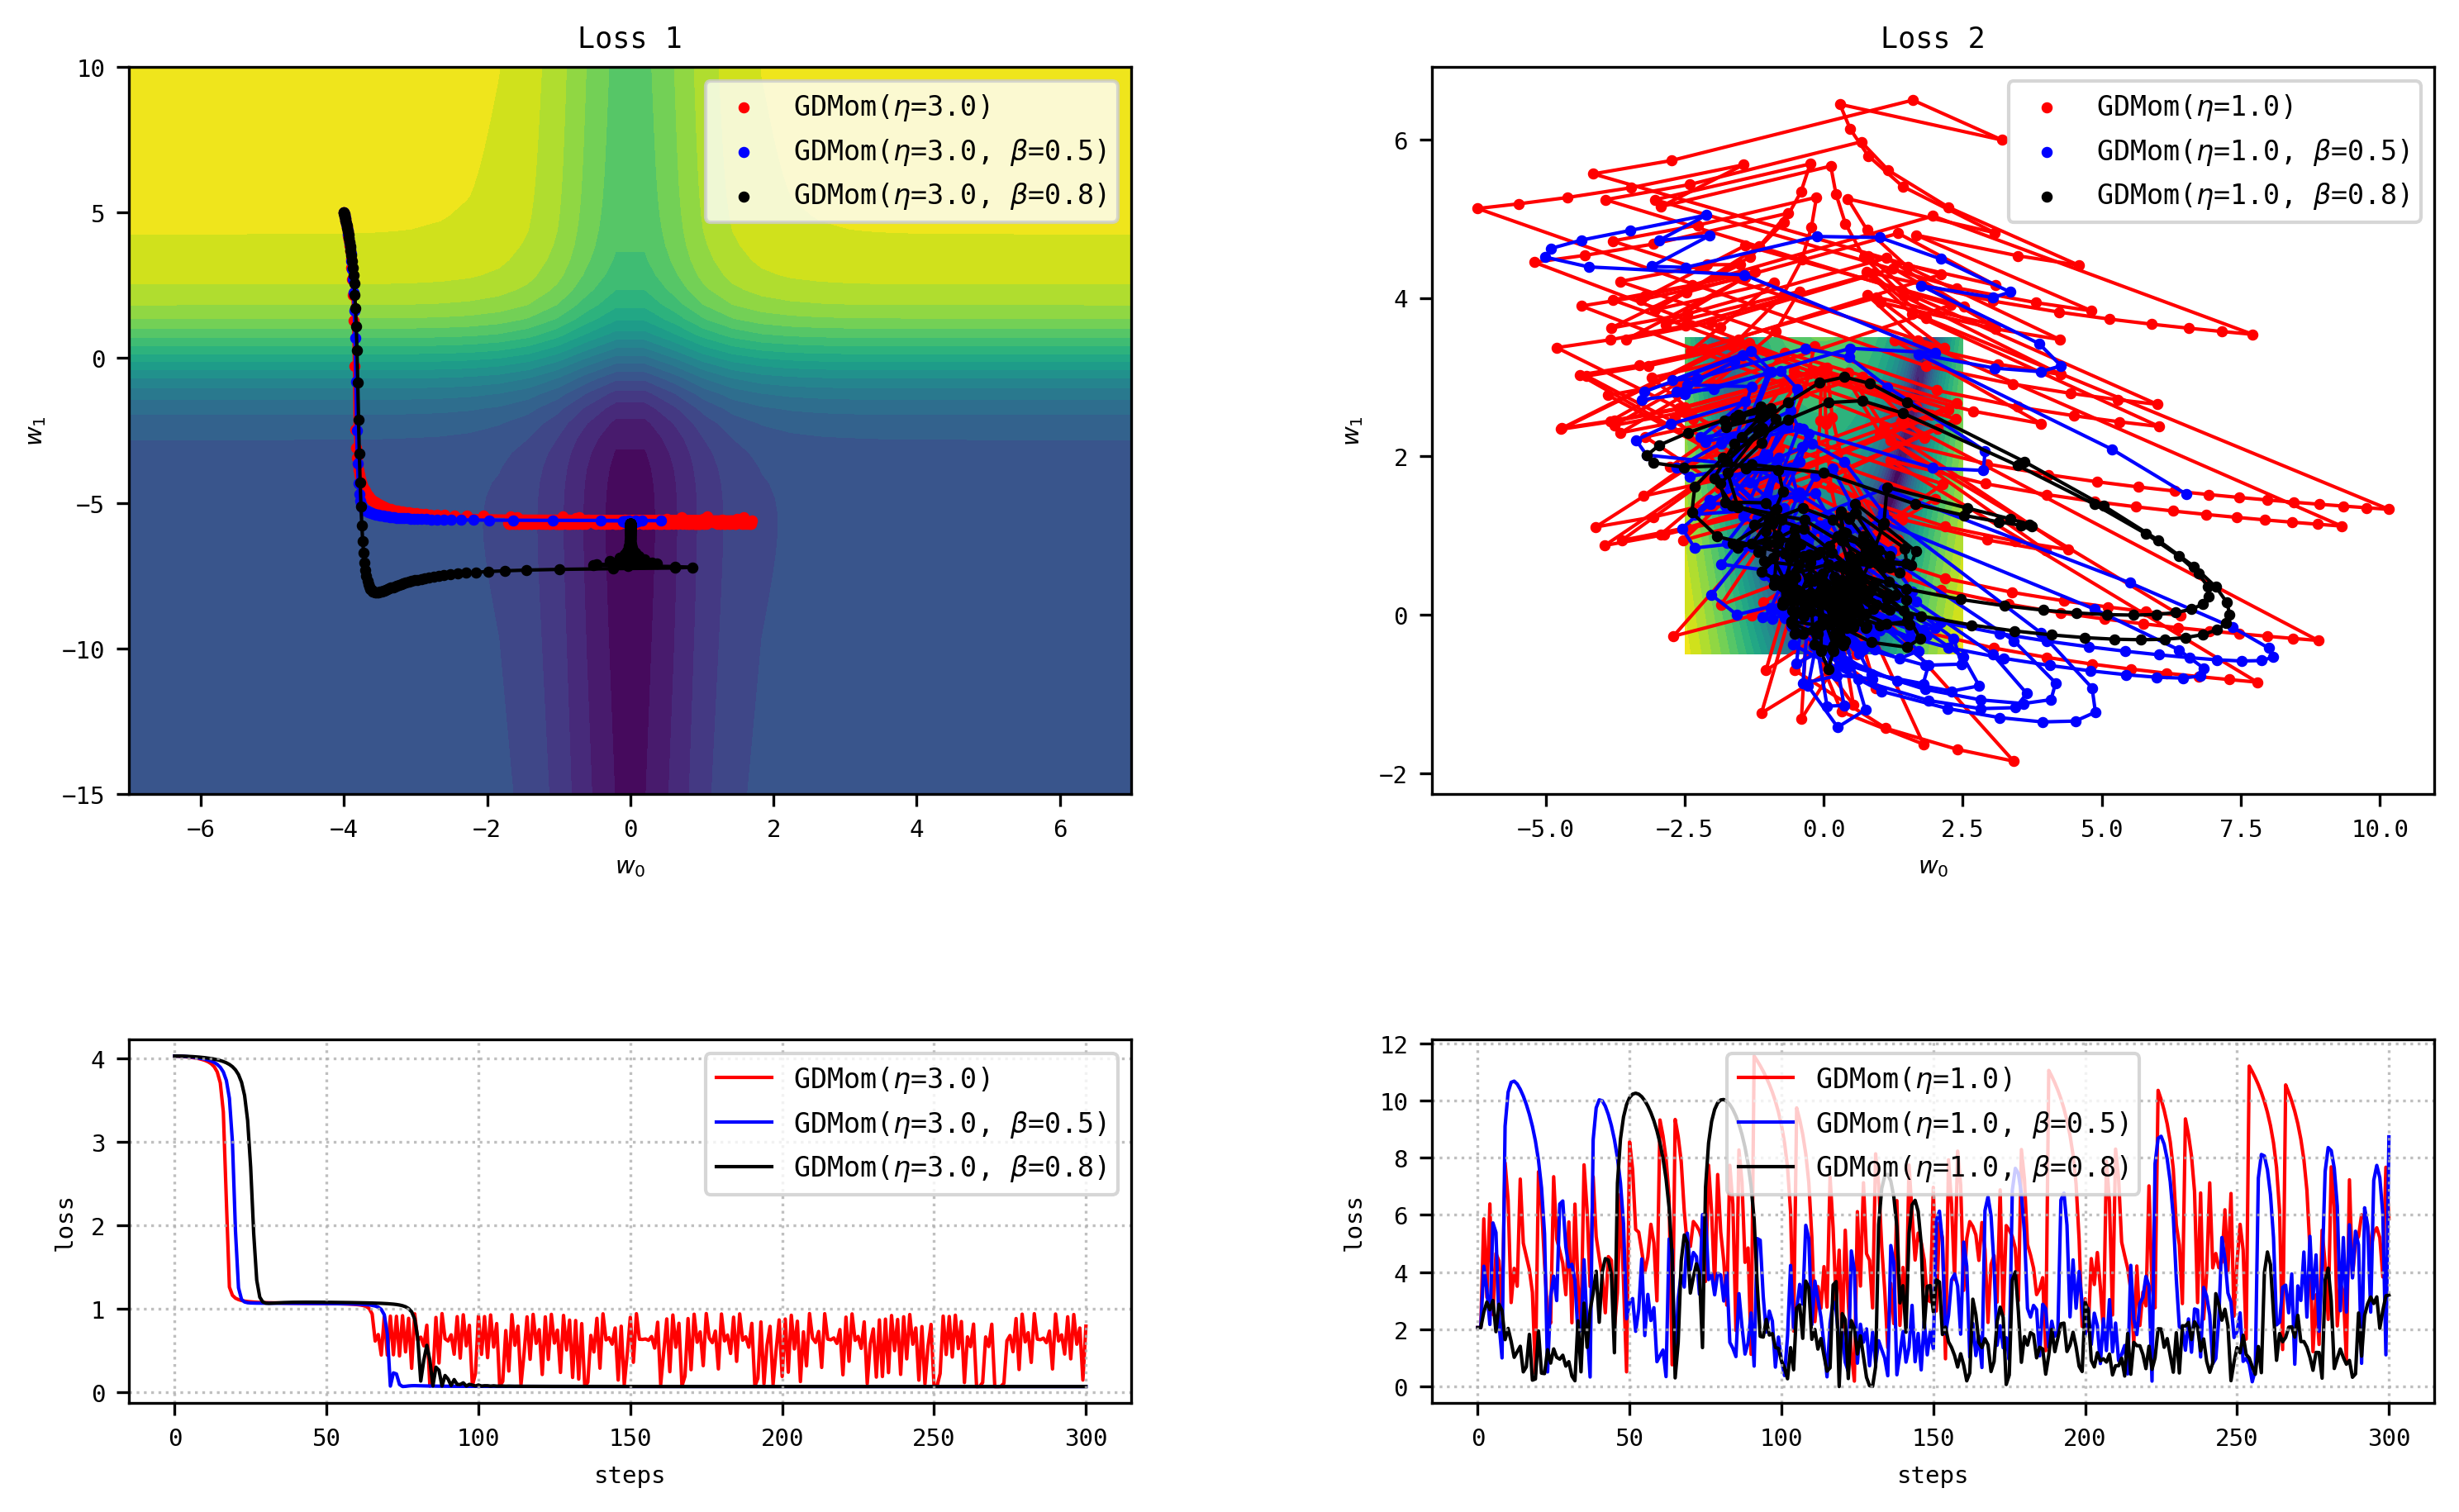

In [10]:
set_plot_params()
lmap = {"lr": r"$\eta$", "momentum": r"$\beta$"}

fig = plt.figure(figsize=(12, 7))
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1], hspace=0.45, wspace=0.3)
ax_tr1 = fig.add_subplot(gs[0, 0])
ax_tr2 = fig.add_subplot(gs[0, 1])
ax_lc1 = fig.add_subplot(gs[1, 0])
ax_lc2 = fig.add_subplot(gs[1, 1])

# Loss 1 — tanh/sigmoid surface
plot_gd_steps([ax_tr1, ax_lc1], GDMom, {"lr": 3.0},                  w_init=[-4.0, 5.0], label_map=lmap, color="red")
plot_gd_steps([ax_tr1, ax_lc1], GDMom, {"lr": 3.0, "momentum": 0.5}, w_init=[-4.0, 5.0], label_map=lmap, color="blue")
plot_gd_steps([ax_tr1, ax_lc1], GDMom, {"lr": 3.0, "momentum": 0.8}, w_init=[-4.0, 5.0], label_map=lmap, color="black")
ax_tr1.set_xlim(-7, 7)
ax_tr1.set_title("Loss 1"); ax_tr1.legend(fontsize=8)
ax_lc1.legend(fontsize=8)

# Loss 2 — Rosenbrock surface (lower lr to avoid divergence)
plot_gd_steps([ax_tr2, ax_lc2], GDMom, {"lr": 1.0},                  w_init=[-1.5, 2.5], label_map=lmap, color="red",
              loss_fn=pathological_loss_2, x_min=-2.5, x_max=2.5, y_min=-0.5, y_max=3.5)
plot_gd_steps([ax_tr2, ax_lc2], GDMom, {"lr": 1.0, "momentum": 0.5}, w_init=[-1.5, 2.5], label_map=lmap, color="blue",
              loss_fn=pathological_loss_2, x_min=-2.5, x_max=2.5, y_min=-0.5, y_max=3.5)
plot_gd_steps([ax_tr2, ax_lc2], GDMom, {"lr": 1.0, "momentum": 0.8}, w_init=[-1.5, 2.5], label_map=lmap, color="black",
              loss_fn=pathological_loss_2, x_min=-2.5, x_max=2.5, y_min=-0.5, y_max=3.5)
ax_tr2.set_title("Loss 2"); ax_tr2.legend(fontsize=8)
ax_lc2.legend(fontsize=8)

fig.tight_layout()


^**Momentum dampens oscillation.** $\beta$ controls how much the previous velocity influences the current update. Higher $\beta$ smooths out the oscillating $w_1$ direction. The $\beta=0.8$ run overshoots the minimum because momentum carries the iterate past zero, but it recovers faster.

[^1]: `state_dict` saves both model and optimizer state. Saving the optimizer is important for accurate resumption of training — the momentum / second-moment buffers must be preserved.


## 4. RMSProp

In vanilla GD, gradient **magnitude** provides a poor signal — near a minimum it vanishes (slowing convergence), on steep slopes it explodes (causing oscillation). The logical fix: normalize each gradient component by its own recent magnitude. **RMSProp** [@rmsprop] estimates the gradient scale with a second exponential average $\mathbf{v}^0 = \mathbf{0}$:

$$
\begin{aligned}
\mathbf{v}^t &= \beta \, \mathbf{v}^{t-1} + (1 - \beta) \, \left( \nabla_{\boldsymbol{\Theta}}\, \mathcal{L}(\boldsymbol{\Theta}^{t}) \right)^2 \\
\boldsymbol{\Theta}^{t+1} &= \boldsymbol{\Theta}^{t} - \eta \, \frac{1}{\sqrt{\mathbf{v}^{t}}} \odot \nabla_{\boldsymbol{\Theta}}\, \mathcal{L}(\boldsymbol{\Theta}^{t})
\end{aligned}
$$

This gives each parameter direction its own **adaptive learning rate**, automatically large in flat directions and small in steep ones.


In [11]:
class RMSProp(OptimizerBase):
    def __init__(self, params, lr, beta=0.9):
        super().__init__(params, lr)
        self.beta = beta
        self.v = {id(p): torch.zeros_like(p.data) for p in self.params}

    def update_param(self, p):
        self.v[id(p)] = self.beta * self.v[id(p)] + (1 - self.beta) * p.grad ** 2
        p += -self.lr * p.grad / torch.sqrt(self.v[id(p)])


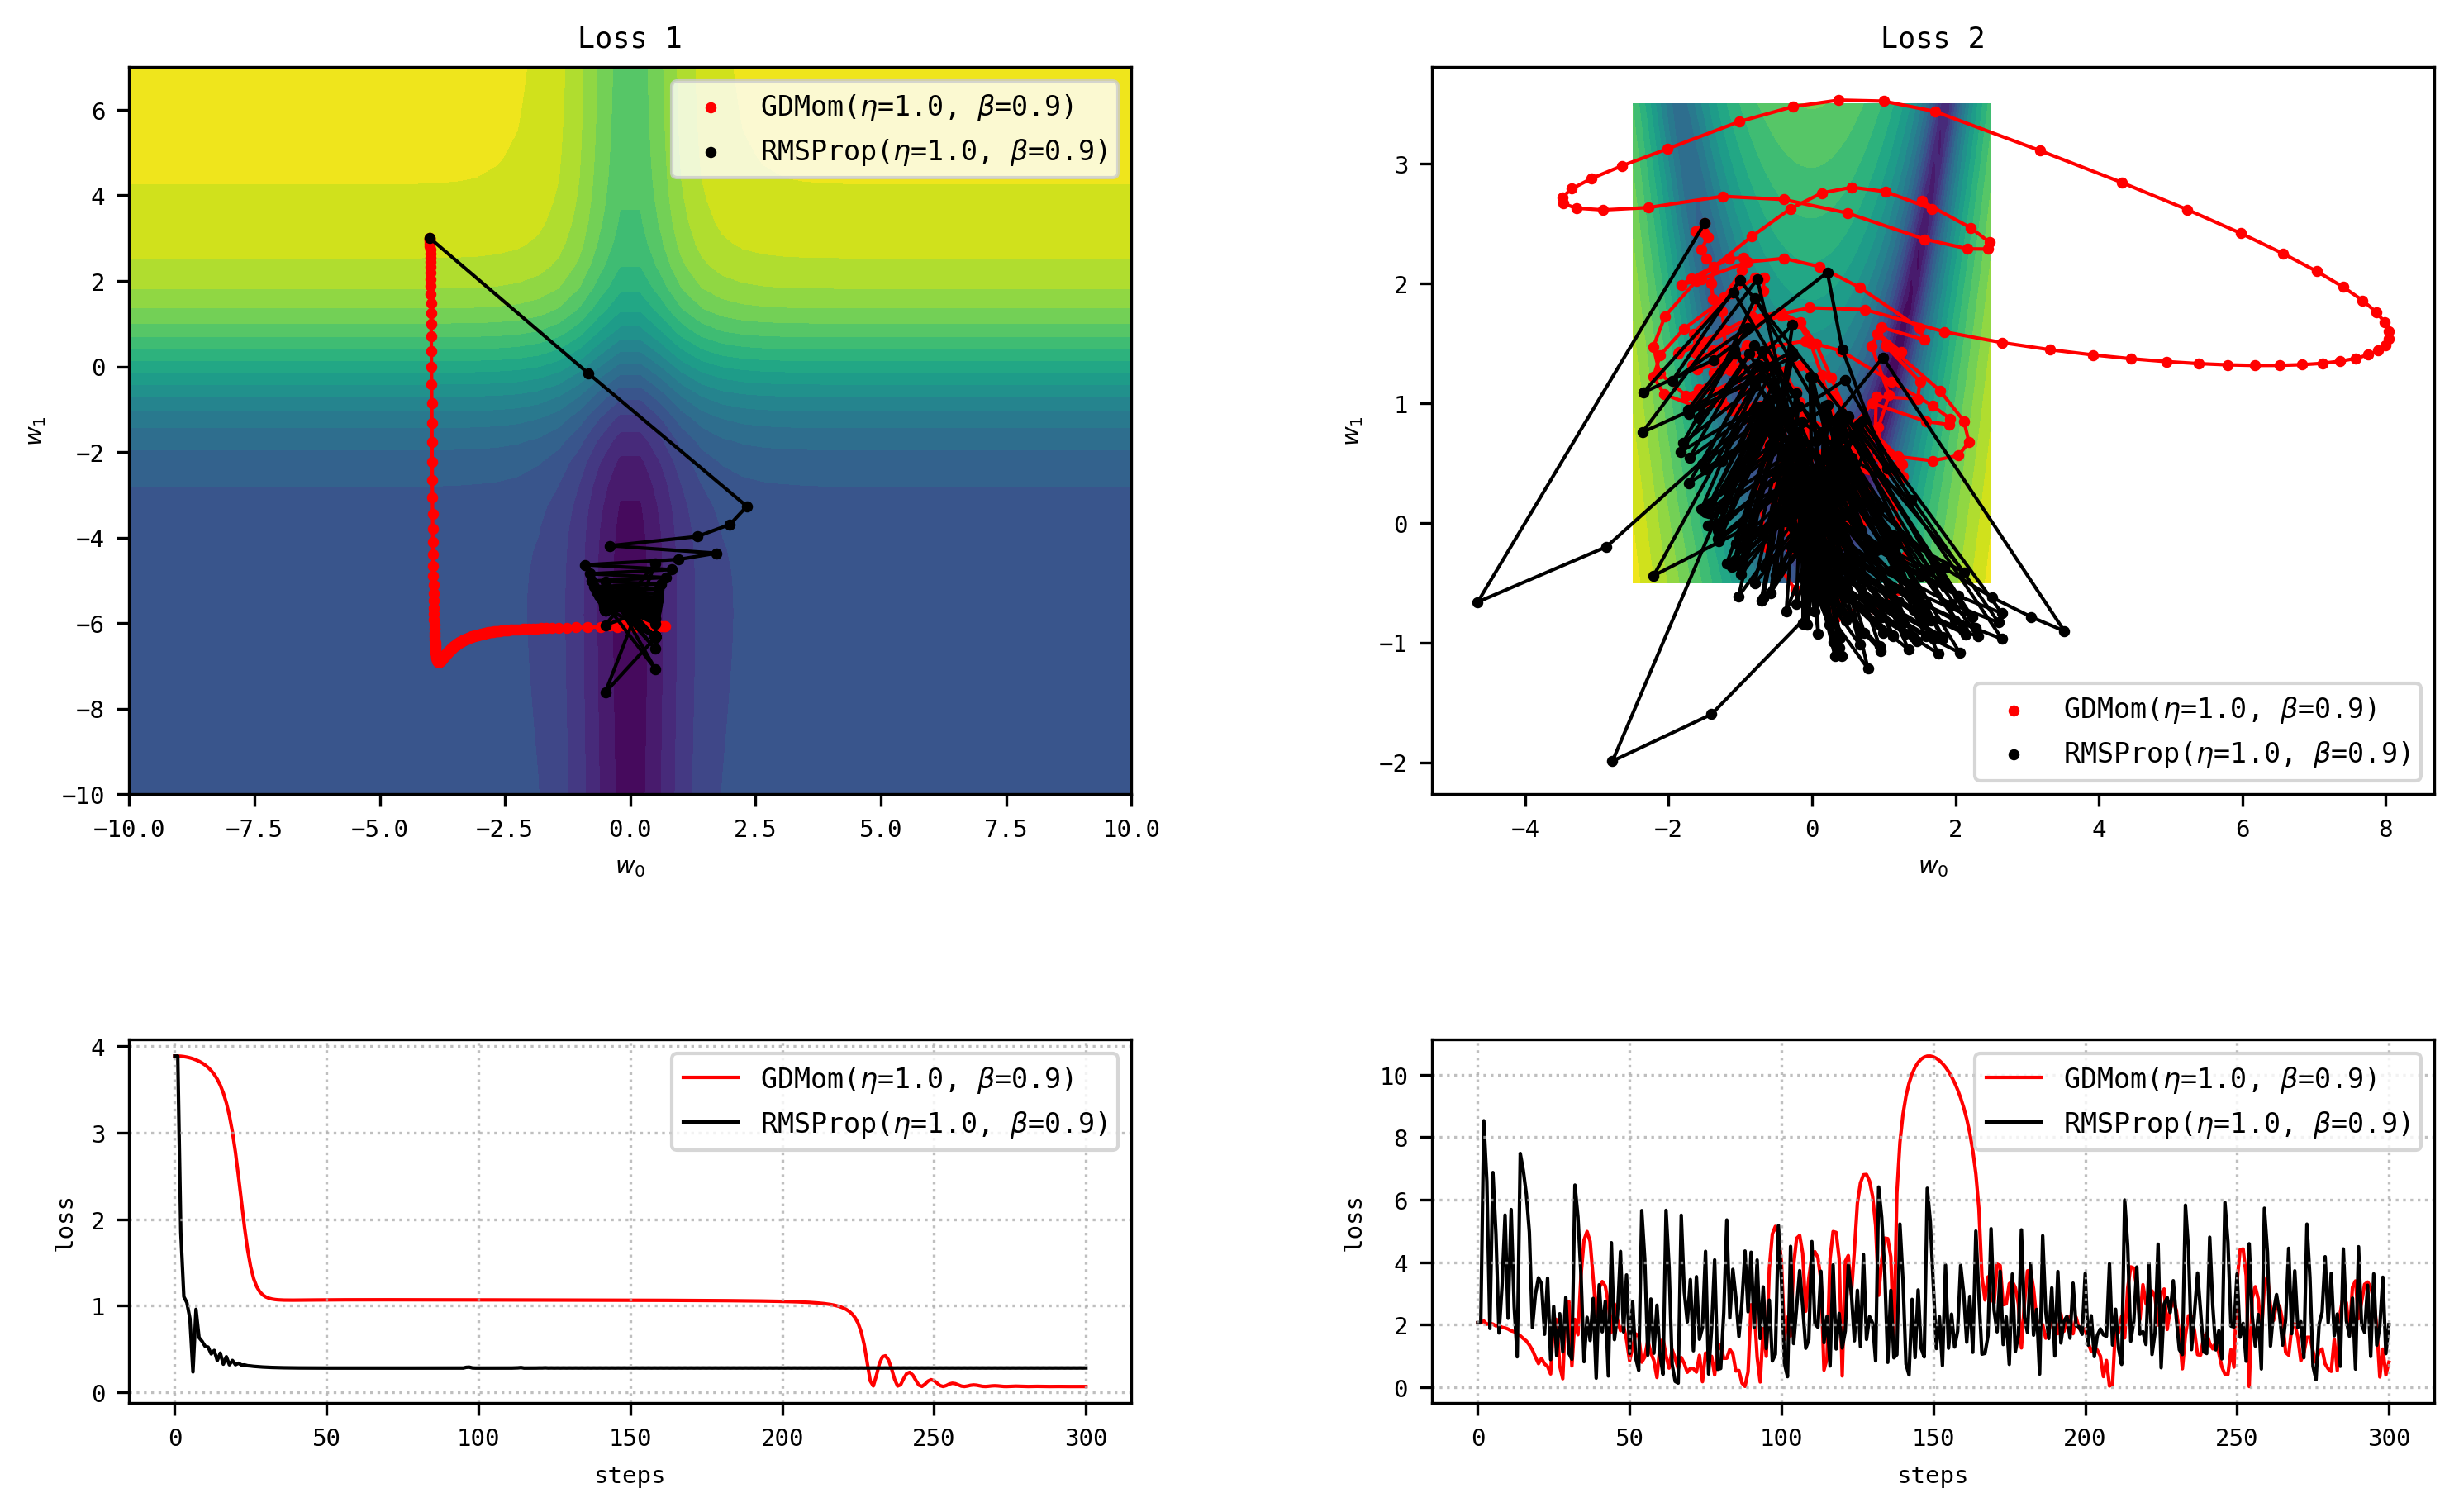

In [12]:
lmap_gdm = {"lr": r"$\eta$", "momentum": r"$\beta$"}
lmap_rms = {"lr": r"$\eta$", "beta": r"$\beta$"}

fig = plt.figure(figsize=(12, 7))
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1], hspace=0.45, wspace=0.3)
ax_tr1 = fig.add_subplot(gs[0, 0])
ax_tr2 = fig.add_subplot(gs[0, 1])
ax_lc1 = fig.add_subplot(gs[1, 0])
ax_lc2 = fig.add_subplot(gs[1, 1])

# Loss 1 — tanh/sigmoid surface
plot_gd_steps([ax_tr1, ax_lc1], GDMom,   {"lr": 1.0, "momentum": 0.9}, w_init=[-4.0, 3.0], label_map=lmap_gdm, color="red")
plot_gd_steps([ax_tr1, ax_lc1], RMSProp, {"lr": 1.0, "beta": 0.9},     w_init=[-4.0, 3.0], label_map=lmap_rms, color="black")
ax_tr1.set_ylim(-10, 7)
ax_tr1.set_title("Loss 1"); ax_tr1.legend(fontsize=8)
ax_lc1.legend(fontsize=8)

# Loss 2 — Rosenbrock surface
plot_gd_steps([ax_tr2, ax_lc2], GDMom,   {"lr": 1.0, "momentum": 0.9}, w_init=[-1.5, 2.5], label_map=lmap_gdm, color="red",
              loss_fn=pathological_loss_2, x_min=-2.5, x_max=2.5, y_min=-0.5, y_max=3.5)
plot_gd_steps([ax_tr2, ax_lc2], RMSProp, {"lr": 1.0, "beta": 0.9},     w_init=[-1.5, 2.5], label_map=lmap_rms, color="black",
              loss_fn=pathological_loss_2, x_min=-2.5, x_max=2.5, y_min=-0.5, y_max=3.5)
ax_tr2.set_title("Loss 2"); ax_tr2.legend(fontsize=8)
ax_lc2.legend(fontsize=8)

fig.tight_layout()


^**RMSProp escapes the plateau, but oscillates near the minimum.** The initial effective step size is $\eta / \sqrt{1 - \beta}$ — larger than $\eta$ — which helps escape plateaus. However, as the gradient varies near the minimum, the adaptive denominator fluctuates and prevents stable convergence. Adam fixes this by adding momentum to the numerator.


## 5. Adam

**Adam** [@adam] fixes RMSProp's oscillation by adding momentum to the numerator (first moment) while keeping RMSProp's adaptive denominator (second moment). Let $\mathbf{g}^t = \nabla_{\boldsymbol{\Theta}}\, \mathcal{L}(\boldsymbol{\Theta}^{t})$ and set $\mathbf{m}^0 = \mathbf{v}^0 = \boldsymbol{0}$, $t = 1$:

$$
\begin{aligned}
\mathbf{m}^t &= \beta_1 \, \mathbf{m}^{t-1} + (1 - \beta_1) \, \mathbf{g}^t \\
\mathbf{v}^t &= \beta_2 \, \mathbf{v}^{t-1} + (1 - \beta_2) \, (\mathbf{g}^t)^2 \\
\hat{\mathbf{m}}^t &= \dfrac{\mathbf{m}^t}{1 - \beta_1^t} \qquad \hat{\mathbf{v}}^t = \dfrac{\mathbf{v}^t}{1 - \beta_2^t} \\
\boldsymbol{\Theta}^{t+1} &= \boldsymbol{\Theta}^{t} - \eta \, \dfrac{\hat{\mathbf{m}}^t}{\sqrt{\hat{\mathbf{v}}^{t}} + \epsilon}
\end{aligned}
$$

Sensible defaults: $\eta = 10^{-3}$, $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\epsilon = 10^{-8}$.


**Bias correction.** Both moments are initialized to zero, causing them to be biased toward zero early in training (too few gradient samples). Dividing by $1 - \beta^t$ corrects this. To see why, expand the recurrence. For the first moment:

$$
\begin{aligned}
\mathbf{m}^1 &= (1 - \beta_1)\, \mathbf{g}^1\\
\mathbf{m}^2 &= (1 - \beta_1)\!\left(\beta_1\,\mathbf{g}^1 + \mathbf{g}^2\right)\\
\mathbf{m}^3 &= (1 - \beta_1)\!\left(\beta_1^2\,\mathbf{g}^1 + \beta_1\,\mathbf{g}^2 + \mathbf{g}^3\right)
\end{aligned}
$$

After $t$ steps, $\mathbf{m}^t = (1 - \beta_1)\sum_{k=1}^{t} \beta_1^{t-k}\,\mathbf{g}^k$, whereas a proper exponential average would sum to 1. The total weight is $(1 - \beta_1)\sum_{k=0}^{t-1}\beta_1^k = 1 - \beta_1^t$, so dividing by this gives the bias-corrected estimate:

$$
\hat{\mathbf{m}}^t = \dfrac{\sum_{k=1}^{t} \beta_1^{t-k}\,\mathbf{g}^k}{\sum_{k=0}^{t-1}\beta_1^k}
$$

At $t = 1$: $\mathbf{m}^1 = (1-\beta_1)\mathbf{g}^1$ but $\hat{\mathbf{m}}^1 = \mathbf{g}^1$ — the first step behaves as if we have a clean gradient estimate regardless of $\beta_1$. Without correction, the momentum term is nearly zero at $t=1$, causing the optimizer to roll down too fast at the start and miss the minimum.


In [13]:
class Adam(OptimizerBase):
    def __init__(self, params, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        super().__init__(params, lr)
        self.beta1 = beta1
        self.beta2 = beta2
        self.t = 0
        self.m = {id(p): torch.zeros_like(p.data) for p in self.params}
        self.v = {id(p): torch.zeros_like(p.data) for p in self.params}
        self.eps = eps

    @torch.no_grad()
    def step(self):
        self.t += 1
        OptimizerBase.step(self)

    def update_param(self, p):
        self.m[id(p)] = self.beta1 * self.m[id(p)] + (1 - self.beta1) * p.grad
        self.v[id(p)] = self.beta2 * self.v[id(p)] + (1 - self.beta2) * p.grad ** 2
        m_hat = self.m[id(p)] / (1 - self.beta1 ** self.t)
        v_hat = self.v[id(p)] / (1 - self.beta2 ** self.t)
        p += -self.lr * m_hat / (torch.sqrt(v_hat) + self.eps)


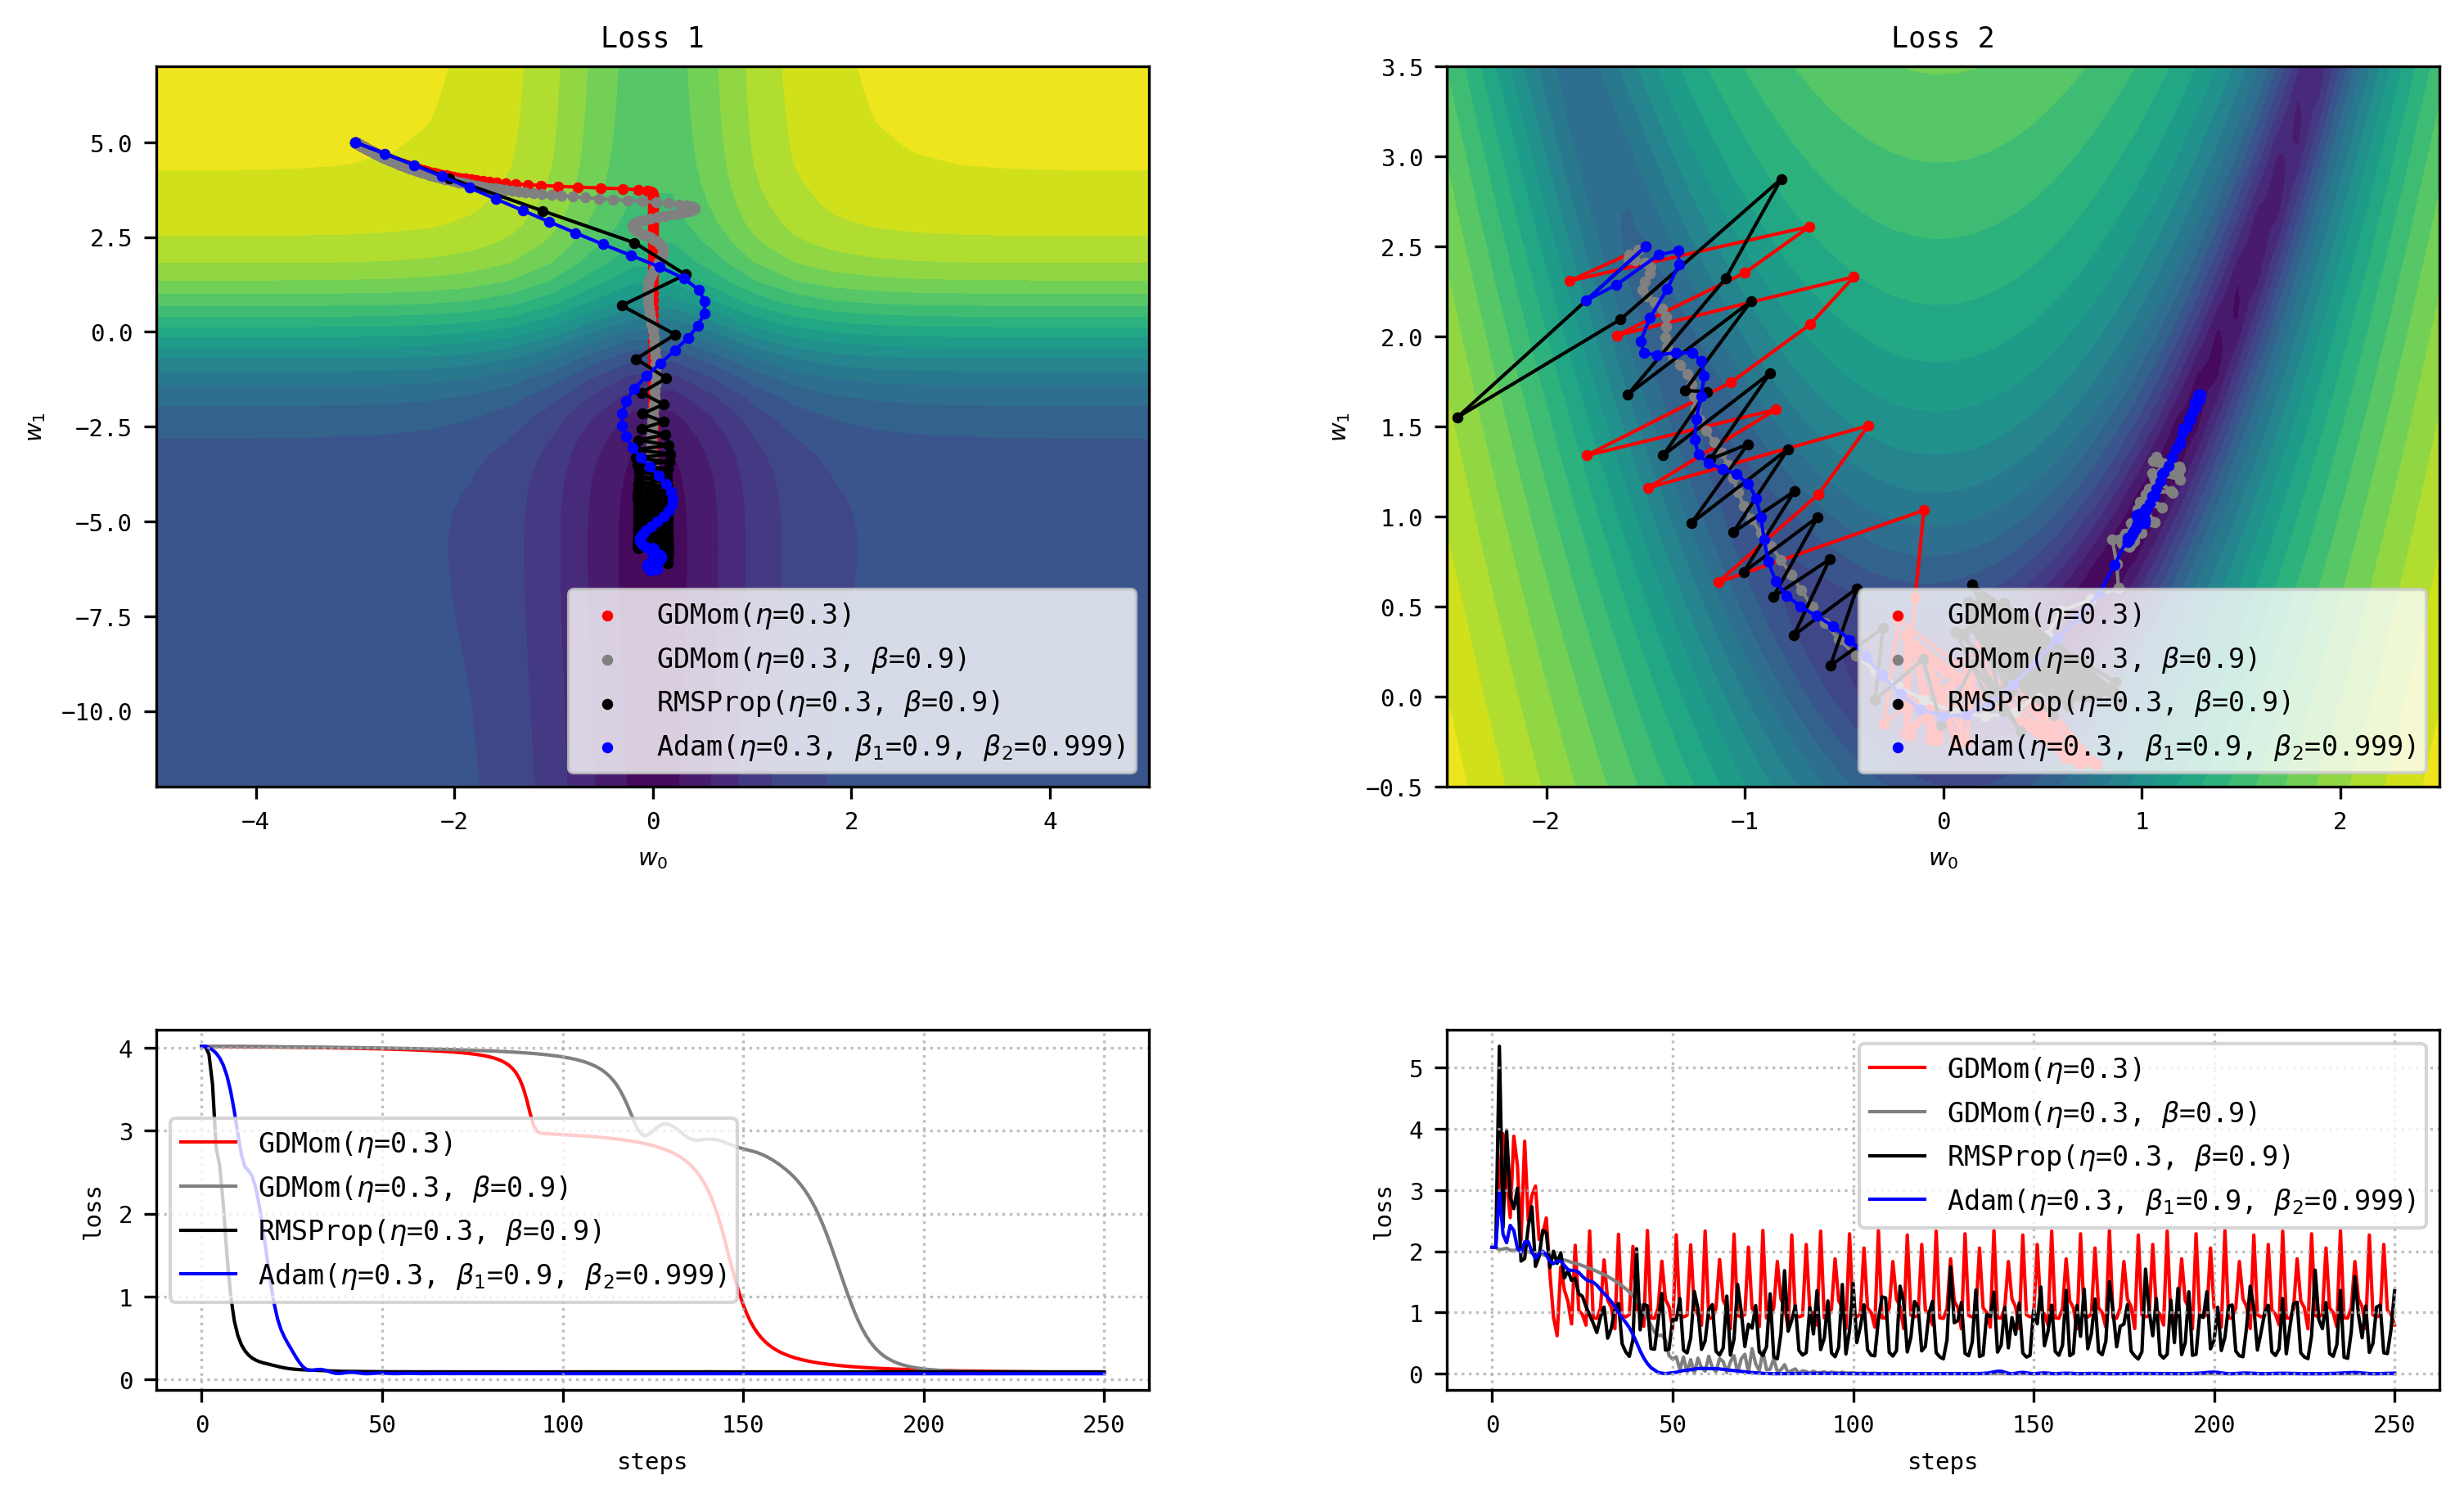

In [14]:
set_plot_params()
lmap_gdm  = {"lr": r"$\eta$", "momentum": r"$\beta$"}
lmap_rms  = {"lr": r"$\eta$", "beta": r"$\beta$"}
lmap_adam = {"lr": r"$\eta$", "beta1": r"$\beta_1$", "beta2": r"$\beta_2$"}

fig = plt.figure(figsize=(12, 7))
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1], hspace=0.45, wspace=0.3)
ax_tr1 = fig.add_subplot(gs[0, 0])
ax_tr2 = fig.add_subplot(gs[0, 1])
ax_lc1 = fig.add_subplot(gs[1, 0])
ax_lc2 = fig.add_subplot(gs[1, 1])

# Loss 1 — tanh/sigmoid surface
plot_gd_steps([ax_tr1, ax_lc1], num_steps=250, optim=GDMom,   optim_params={"lr": 0.3},
              w_init=[-3, 5], label_map=lmap_gdm,  color="red")
plot_gd_steps([ax_tr1, ax_lc1], num_steps=250, optim=GDMom,   optim_params={"lr": 0.3, "momentum": 0.9},
              w_init=[-3, 5], label_map=lmap_gdm,  color="gray")
plot_gd_steps([ax_tr1, ax_lc1], num_steps=250, optim=RMSProp, optim_params={"lr": 0.3, "beta": 0.9},
              w_init=[-3, 5], label_map=lmap_rms,  color="black")
plot_gd_steps([ax_tr1, ax_lc1], num_steps=250, optim=Adam,    optim_params={"lr": 0.3, "beta1": 0.9, "beta2": 0.999},
              w_init=[-3, 5], label_map=lmap_adam, color="blue")
ax_tr1.set_xlim(-5, 5); ax_tr1.set_ylim(-12, 7)
ax_tr1.set_title("Loss 1"); ax_tr1.legend(fontsize=8, loc="lower right")
ax_lc1.legend(fontsize=8)

# Loss 2 — Rosenbrock surface
plot_gd_steps([ax_tr2, ax_lc2], num_steps=250, optim=GDMom,   optim_params={"lr": 0.3},
              w_init=[-1.5, 2.5], label_map=lmap_gdm,  color="red",
              loss_fn=pathological_loss_2, x_min=-2.5, x_max=2.5, y_min=-0.5, y_max=3.5)
plot_gd_steps([ax_tr2, ax_lc2], num_steps=250, optim=GDMom,   optim_params={"lr": 0.3, "momentum": 0.9},
              w_init=[-1.5, 2.5], label_map=lmap_gdm,  color="gray",
              loss_fn=pathological_loss_2, x_min=-2.5, x_max=2.5, y_min=-0.5, y_max=3.5)
plot_gd_steps([ax_tr2, ax_lc2], num_steps=250, optim=RMSProp, optim_params={"lr": 0.3, "beta": 0.9},
              w_init=[-1.5, 2.5], label_map=lmap_rms,  color="black",
              loss_fn=pathological_loss_2, x_min=-2.5, x_max=2.5, y_min=-0.5, y_max=3.5)
plot_gd_steps([ax_tr2, ax_lc2], num_steps=250, optim=Adam,    optim_params={"lr": 0.3, "beta1": 0.9, "beta2": 0.999},
              w_init=[-1.5, 2.5], label_map=lmap_adam, color="blue",
              loss_fn=pathological_loss_2, x_min=-2.5, x_max=2.5, y_min=-0.5, y_max=3.5)
ax_tr2.set_title("Loss 2"); ax_tr2.legend(fontsize=8, loc="lower right")
ax_lc2.legend(fontsize=8)

fig.tight_layout()


^**Adam converges stably.** At the start, all step sizes are $\approx \eta$ (bias correction ensures this). The adaptive denominator then regulates each dimension independently, and momentum in the numerator damps oscillation. For RMSProp, the oscillations persist because nothing smooths the noisy gradient direction.

**Default hyperparameters.**

| Param | Default | Role |
|---|---|---|
| $\eta$ | $10^{-3}$ | Overall step size |
| $\beta_1$ | $0.9$ | Momentum of gradient direction |
| $\beta_2$ | $0.999$ | Momentum of gradient magnitude |
| $\epsilon$ | $10^{-8}$ | Numerical stability |

For language model training, $\beta_2 = 0.95$ (GPT-3, NanoGPT) is often preferred over $0.999$. The second moment memory length is $\approx 1/(1-\beta_2)$ steps. A shorter memory (0.95 $\approx$ 20 steps) makes adaptive scaling more responsive during the rapid gradient changes of large-scale pretraining.


## 6. AdamW

### The problem with Adam + L2 regularization

The natural way to add weight decay is to add an L2 penalty $\lambda\lVert\boldsymbol{\Theta}\rVert^2$ to the loss, which adds $\lambda\boldsymbol{\Theta}$ to the gradient. For SGD, this is exactly equivalent to weight decay: $\boldsymbol{\Theta}^{t+1} = (1 - 2\eta\lambda)\boldsymbol{\Theta}^t - \eta\mathbf{g}^t$.

For Adam, they are **not equivalent**. The regularization gradient gets passed through the adaptive scaling:

$$\boldsymbol{\Theta}^{t+1} = \boldsymbol{\Theta}^{t} - \eta \cdot \frac{\hat{\mathbf{m}}^t + \lambda\boldsymbol{\Theta}^t}{\sqrt{\hat{\mathbf{v}}^{t}} + \epsilon}$$

The weight decay term is *divided by* $\sqrt{\hat{\mathbf{v}}^t}$. Parameters with large gradient history (large $\hat{\mathbf{v}}^t$ — precisely the important, frequently-updated parameters) have their regularization **suppressed**. L2 decay is weakest exactly where you want it strongest.

### The fix: decouple weight decay

**AdamW** [@adamw] (Loshchilov & Hutter, 2019) applies weight decay *after* the adaptive update, as direct parameter shrinkage:

$$\boldsymbol{\Theta}^{t+1} = \boldsymbol{\Theta}^{t} - \eta \cdot \frac{\hat{\mathbf{m}}^t}{\sqrt{\hat{\mathbf{v}}^{t}} + \epsilon} - \eta\lambda\boldsymbol{\Theta}^{t}$$

The term $\eta\lambda\boldsymbol{\Theta}^t$ is pure shrinkage — every parameter experiences the same regularization pressure regardless of gradient history. [Always use AdamW instead of Adam + L2 for neural networks.]{.mark}


In [15]:
class AdamW(OptimizerBase):
    def __init__(self, params, lr=0.001, beta1=0.9, beta2=0.999,
                 eps=1e-8, weight_decay=0.0):
        super().__init__(params, lr)
        self.beta1 = beta1
        self.beta2 = beta2
        self.t = 0
        self.m = {id(p): torch.zeros_like(p.data) for p in self.params}
        self.v = {id(p): torch.zeros_like(p.data) for p in self.params}
        self.eps = eps
        self.weight_decay = weight_decay

    @torch.no_grad()
    def step(self):
        self.t += 1
        OptimizerBase.step(self)

    def update_param(self, p):
        self.m[id(p)] = self.beta1 * self.m[id(p)] + (1 - self.beta1) * p.grad
        self.v[id(p)] = self.beta2 * self.v[id(p)] + (1 - self.beta2) * p.grad ** 2
        m_hat = self.m[id(p)] / (1 - self.beta1 ** self.t)
        v_hat = self.v[id(p)] / (1 - self.beta2 ** self.t)
        # Adaptive update (same as Adam)
        p.data.addcdiv_(m_hat, v_hat.sqrt().add_(self.eps), value=-self.lr)
        # Weight decay — decoupled, not through adaptive scaling
        p.data.mul_(1 - self.lr * self.weight_decay)


### Which parameters to weight-decay

Not all parameters benefit from regularization. The standard split:

- **Decay**: weight matrices (`nn.Linear` weights, attention projections, FFN weights).
- **No decay**: bias terms, layer norm scale/shift, embedding tables — these are 1-D or serve as additive offsets; regularizing them hurts.


In [16]:
def make_optimizer(model, lr, weight_decay=0.1, betas=(0.9, 0.95)):
    decay_params, no_decay_params = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if p.ndim >= 2:        # weight matrices
            decay_params.append(p)
        else:                  # biases, layer norm params (1-D)
            no_decay_params.append(p)

    param_groups = [
        {"params": decay_params,    "weight_decay": weight_decay},
        {"params": no_decay_params, "weight_decay": 0.0},
    ]
    return torch.optim.AdamW(param_groups, lr=lr, betas=betas)

# Example
model = nn.Sequential(nn.Linear(256, 256), nn.GELU(), nn.Linear(256, 10))
optimizer = make_optimizer(model, lr=3e-4)
print(optimizer)


AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.95)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0003
    maximize: False
    weight_decay: 0.1

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.95)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0003
    maximize: False
    weight_decay: 0.0
)


### Comparing Adam, Adam+L2, and AdamW

We can verify the AdamW advantage empirically. The same small network is trained with three optimizer configurations. Note that setting `weight_decay` in `torch.optim.Adam` adds the penalty **before** adaptive scaling (Adam + L2), while `torch.optim.AdamW` applies it **after** (decoupled). We track train loss, validation loss, and total weight norm:


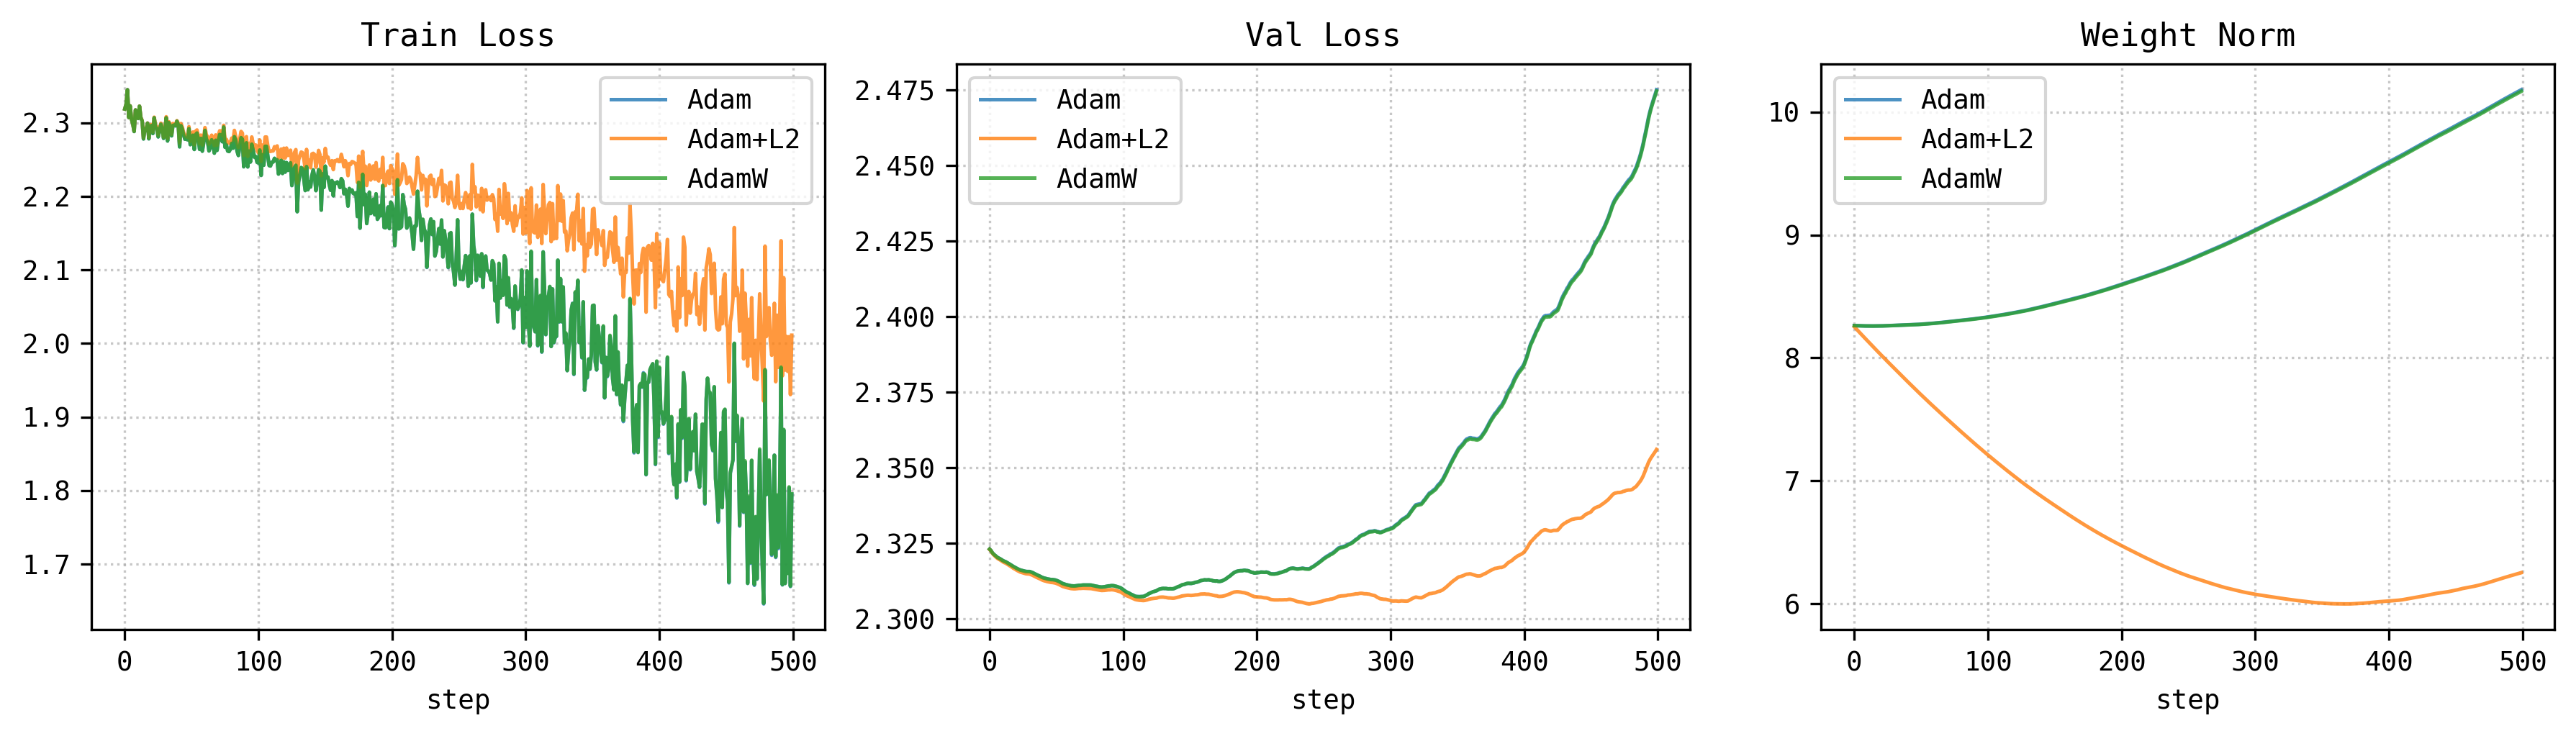

In [17]:
def train_and_eval(optimizer_fn, steps=500, seed=42):
    torch.manual_seed(seed)
    model = nn.Sequential(nn.Linear(64, 128), nn.ReLU(),
                          nn.Linear(128, 64), nn.ReLU(),
                          nn.Linear(64, 10))
    opt = optimizer_fn(model.parameters())

    torch.manual_seed(seed)
    X = torch.randn(1000, 64); Y = torch.randint(0, 10, (1000,))
    X_val = torch.randn(200, 64); Y_val = torch.randint(0, 10, (200,))

    train_losses, val_losses, weight_norms = [], [], []
    for step in range(steps):
        idx = torch.randint(0, 1000, (64,))
        opt.zero_grad()
        logits = model(X[idx])
        loss   = nn.functional.cross_entropy(logits, Y[idx])
        loss.backward()
        opt.step()

        train_losses.append(loss.item())
        with torch.no_grad():
            val_loss = nn.functional.cross_entropy(model(X_val), Y_val)
            val_losses.append(val_loss.item())
            wn = sum(p.norm().item()**2 for p in model.parameters())**0.5
            weight_norms.append(wn)

    return train_losses, val_losses, weight_norms

set_plot_params({"font.size": 9, "lines.linewidth": 1.2})
results = {
    'Adam':    train_and_eval(lambda p: torch.optim.Adam(p, lr=3e-4)),
    'Adam+L2': train_and_eval(lambda p: torch.optim.Adam(p, lr=3e-4, weight_decay=0.01)),
    'AdamW':   train_and_eval(lambda p: torch.optim.AdamW(p, lr=3e-4, weight_decay=0.01)),
}

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for name, (tl, vl, wn) in results.items():
    axes[0].plot(tl, label=name, alpha=0.8)
    axes[1].plot(vl, label=name, alpha=0.8)
    axes[2].plot(wn, label=name, alpha=0.8)

for ax, title in zip(axes, ['Train Loss', 'Val Loss', 'Weight Norm']):
    ax.set(title=title, xlabel='step')
    ax.legend()
    ax.grid(linestyle='dotted', alpha=0.7)
plt.tight_layout(); plt.show()


^**AdamW maintains lower, more consistent weight norms** than Adam+L2. The decoupled shrinkage treats every parameter equally, while Adam+L2's effective weight decay is suppressed for parameters with large gradient history — precisely those that would benefit most from regularization.


## 7. Stochastic Gradient Descent (SGD)

Computing the exact gradient requires a forward pass over the entire dataset — prohibitively expensive for large-scale problems. The key insight: $\mathcal{L}_\mathcal{D}$ is itself only an estimate of the true loss (finite sample approximation), so we can replace it with a mini-batch estimate $\mathcal{L}_{\mathcal{B}}$ over a random subset $\mathcal{B} \subset \mathcal{D}$ of size $B \ll |\mathcal{D}|$:

$$\boldsymbol{\Theta}^{t+1} = \boldsymbol{\Theta}^t - \eta \, \nabla_{\boldsymbol{\Theta}} \mathcal{L}_{\mathcal{B}}(\boldsymbol{\Theta}^t)$$

**The gradient estimate is unbiased.** Shuffling the dataset and slicing makes each element of $\mathcal{B}$ uniformly distributed over the full dataset:

$$\mathbb{E}\!\left[\frac{1}{B}\sum_{j=1}^B \nabla\mathcal{L}_{\mathcal{B},j}(\boldsymbol{\Theta})\right] = \nabla\mathcal{L}(\boldsymbol{\Theta})$$

**Variance scales as $1/B$.** Assuming independent mini-batch samples:

$$\mathbb{V}\text{ar}\!\left(\frac{1}{B}\sum_{j=1}^B \nabla\mathcal{L}_{\mathcal{B},j}\right) = \frac{1}{B}\,\mathbb{V}\text{ar}\!\left(\nabla\mathcal{L}_{\mathcal{B},1}\right)$$

This noise is not merely a nuisance — [it acts as implicit regularization by preventing the optimizer from converging to sharp, narrow minima]{.mark} [@sgd_better_than_adam]. Typical values: $B = 32, 64, 128, 256$.


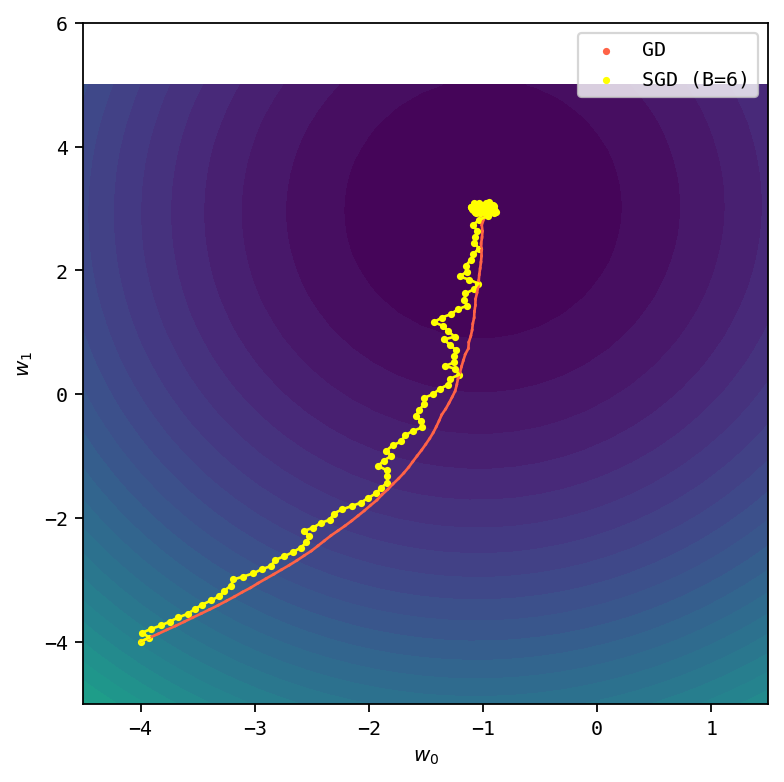

In [18]:
from functools import partial

def loss_mse(w0, w1, X, y):
    return ((X @ np.array([w0, w1]) - y)**2).mean()

def grad_normalized(w, X, y):
    dw = 2 * ((X @ w - y).reshape(-1, 1) * X).mean(axis=0)
    return dw / np.linalg.norm(dw)

def sgd_np(w0, X, y, eta=0.1, steps=300, B=32):
    w = np.zeros([steps, 2])
    w[0, :] = w0
    for j in range(1, steps):
        batch = torch.randint(0, len(X), size=(B,)).numpy()
        w[j, :] = w[j-1, :] - eta * grad_normalized(w[j-1, :], X[batch], y[batch])
    return w

# Generate linear regression data: y = -1 + 3x + noise
np.random.seed(0)
B_small = 6
n_data  = 1000
X_data  = np.column_stack([np.ones(n_data),
                            np.random.uniform(-1, 1, n_data)])
y_data  = X_data @ np.array([-1, 3]) + 0.05 * np.random.randn(n_data)

w_init = [-4, -4]
path_gd  = sgd_np(w_init, X_data, y_data, eta=0.1, B=n_data)
path_sgd = sgd_np(w_init, X_data, y_data, eta=0.1, B=B_small)

fig, ax = plt.subplots(1, 1, figsize=(5, 5), dpi=80)
plot_contourf(ax, partial(loss_mse, X=X_data, y=y_data),
              path_gd,  color="tomato", levels=50, x_min=-5, y_max=5, label="GD")
plot_contourf(ax, partial(loss_mse, X=X_data, y=y_data),
              path_sgd, color="yellow", levels=50, x_min=-5, y_max=5, label=f"SGD (B={B_small})")
ax.set_ylim(-5, 6); ax.set_xlim(-4.5, 1.5)
ax.legend(); fig.tight_layout();


^**SGD steps are noisy compared to GD.** The mini-batch gradient is an unbiased estimate of the full-batch gradient but has high variance at $B=6$. In practice, the dataset is **shuffled once per epoch** and iterated in consecutive slices — sampling without replacement is more data-efficient than random sampling. A PyTorch `DataLoader` handles this automatically:


In [19]:
from torch.utils.data import DataLoader

dataset = torch.arange(10)
loader  = DataLoader(dataset, batch_size=2, shuffle=True)

print("Epoch 1:")
[print(x) for x in loader]
print()
print("Epoch 2:")
[print(x) for x in loader];


Epoch 1:
tensor([7, 9])
tensor([4, 3])
tensor([0, 1])
tensor([8, 5])
tensor([2, 6])

Epoch 2:
tensor([1, 9])
tensor([5, 6])
tensor([8, 7])
tensor([2, 4])
tensor([3, 0])


## 8. Batch Size

### Gradient noise scale and the critical batch size

The **gradient noise scale** $B^*$ is the batch size at which marginal returns from adding more samples diminish:

$$B^* = \frac{\text{tr}(\boldsymbol{\Sigma})}{\lVert\boldsymbol{g}_{\text{true}}\rVert^2}$$

where $\boldsymbol{\Sigma}$ is the covariance of per-sample gradients and $\boldsymbol{g}_{\text{true}}$ is the true gradient.

- $B \ll B^*$: noisy gradients; stochastic exploration helps early training and avoids sharp minima.
- $B \gg B^*$: diminishing returns per sample; extra computation yields little improvement.
- $B \approx B^*$: [**critical batch size** — maximum gradient quality per FLOP]{.mark}.

For LLM training, $B^*$ is typically in the range of 100K–500K tokens per step.

### The linear scaling rule

Doubling $B$ halves gradient variance. To compensate, learning rate can be scaled proportionally [@imagenet1hour]:

$$\eta_\text{new} = \eta_\text{base} \times \frac{B_\text{new}}{B_\text{base}}$$

![Linear scaling used to train ResNet-50 on ImageNet in 1 hour (256 GPUs). **Source:** [@imagenet1hour]](./img/02-imagenet-1-hour.png){#fig-02-imagenet-1-hour fig-align="center" width="500px"}

This rule holds up to the critical batch size ($B \lesssim B^*$). Beyond it, larger batches degrade generalization even with tuned LR — they converge to **sharper** minima [@sharp_minima_bad].

### Batch size and generalization

[Smaller batches generally **generalize better**:]{.mark}

1. **Noise as implicit regularization:** mini-batch noise prevents the optimizer from converging to sharp, narrow minima. Large batches converge to sharper minima that generalize poorly.
2. **More gradient steps per epoch:** smaller batches yield more parameter updates per data pass, which can accelerate early convergence.

For fine-tuning (near a good initialization), small batch sizes (8–32) often outperform large ones. For pretraining, compute efficiency dominates and larger batches are preferred. See Fig. 6 of [@mccandlish2018] for a systematic empirical study.

Gradient accumulation — simulating large batches by accumulating gradients across micro-batches — is covered in [Tutorial 8](../llm/tutorial_08_optimizers.ipynb), including the correct interaction with mixed-precision training and a common silent bug to avoid.


## 9. Learning Rate

### Finding a base learning rate

The **LR range test** sweeps $\eta$ exponentially over 100–200 steps while recording the loss. The optimal base LR is slightly before the loss starts to rise sharply. This is parameter-free and takes only seconds:


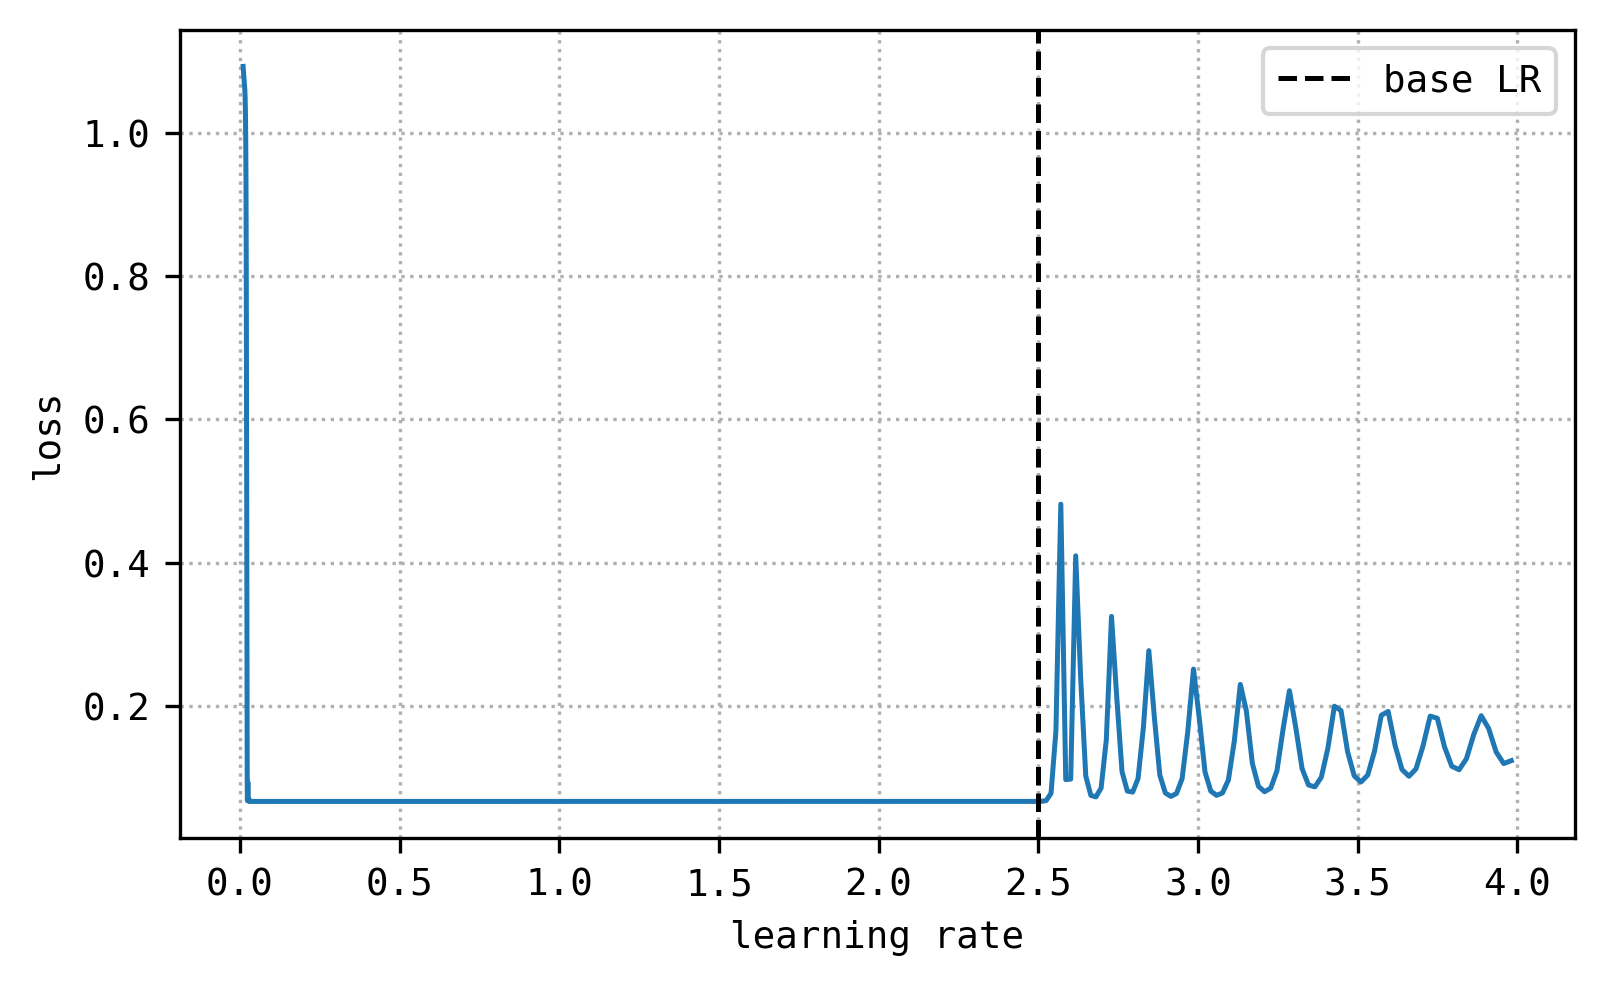

In [20]:
num_steps = 1000
lre_min, lre_max = -2.0, 0.6
lre = torch.linspace(lre_min, lre_max, num_steps)
lrs = 10 ** lre

w = nn.Parameter(torch.FloatTensor([-4.0, -4.0]), requires_grad=True)
optim = Adam([w], lr=lrs[0].item())

losses = []
for k in range(num_steps):
    optim.lr = lrs[k].item()
    optim.zero_grad()
    loss = pathological_loss(w[0], w[1])
    loss.backward()
    optim.step()
    losses.append(loss.item())

plt.figure(figsize=(6, 3.5))
plt.plot(lrs.detach(), losses)
plt.xlabel("learning rate")
plt.ylabel("loss")
plt.grid(linestyle="dotted")
plt.axvline(2.5, color="k", linestyle="dashed", label="base LR")
plt.legend();


^**LR range test on the pathological loss.** The loss declines as LR increases, then diverges sharply. `lr ≈ 2.0–2.5` is the sweet spot before divergence. Note: sampling is biased toward lower LRs since large LR causes early divergence.

### LR scheduling

A fixed LR rarely performs best throughout training: large early (to escape plateaus), small late (for stable convergence). The common strategy is to **schedule** $\eta$ to decay over time. A simple step decay is added as an optional callback in `train_curve`:


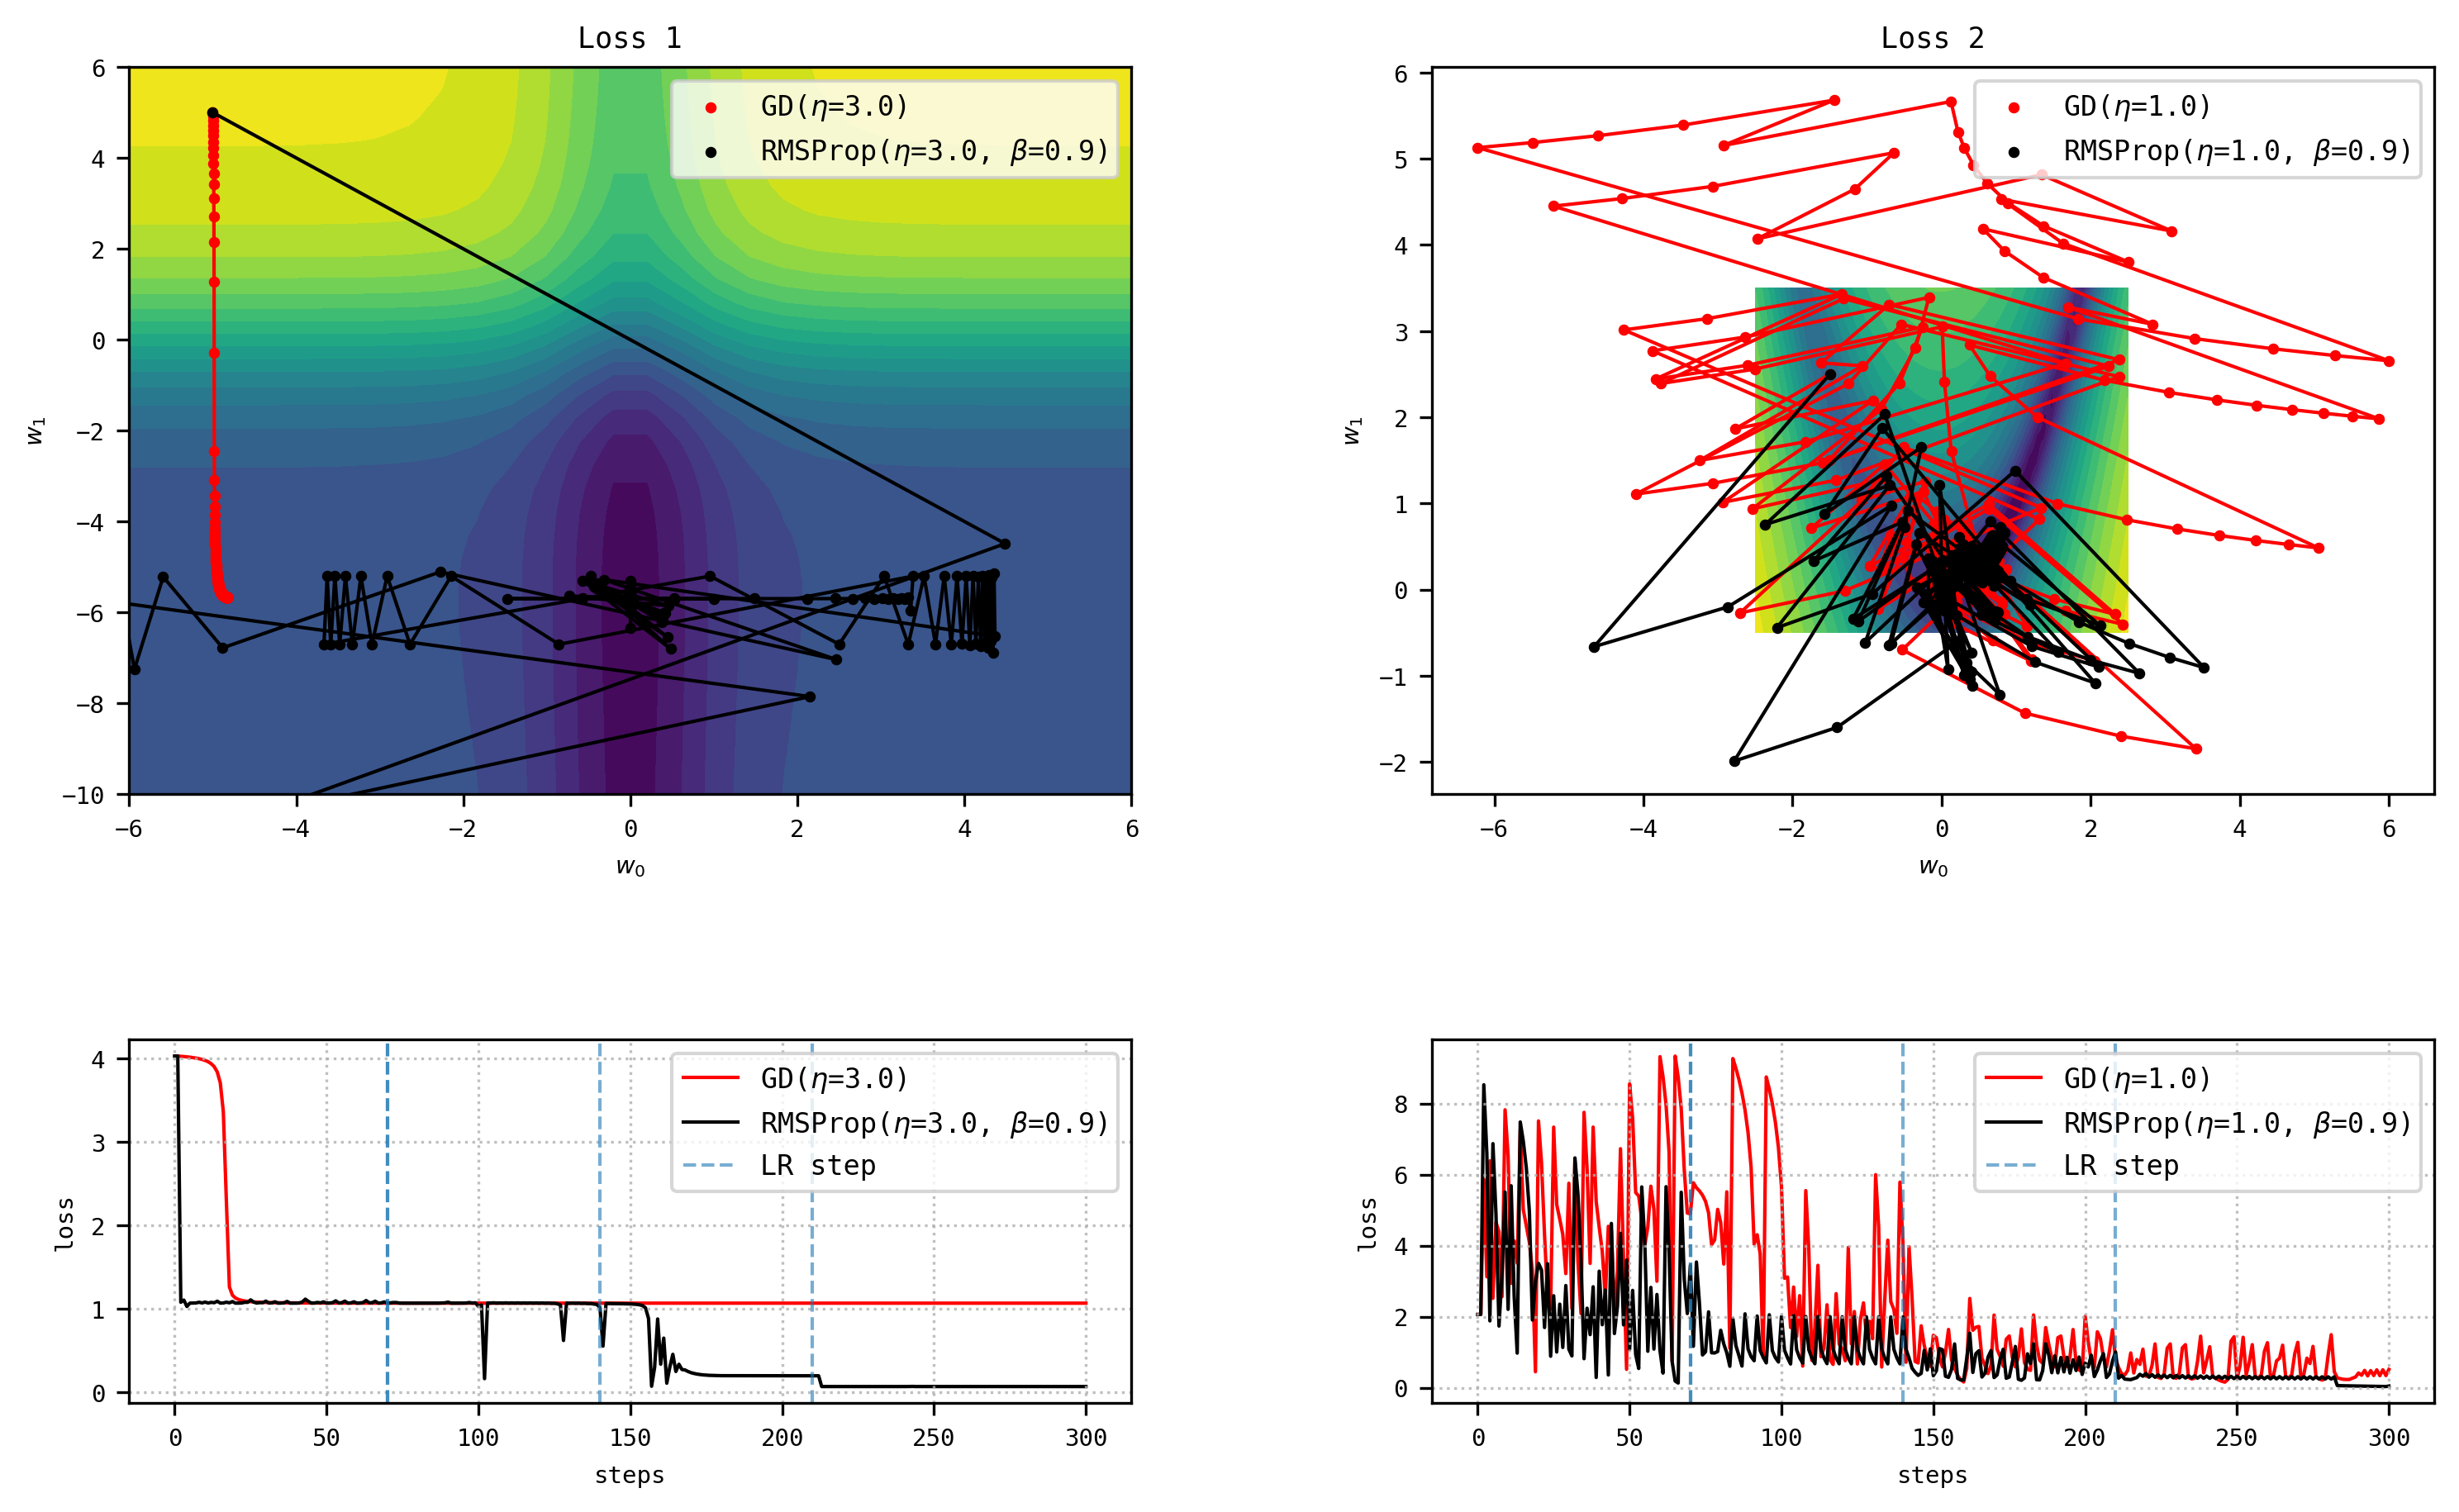

In [21]:
def step_decay(optim, step):
    if step > 0 and step % 70 == 0:
        optim.lr *= 0.5

set_plot_params()
lmap_gd  = {"lr": r"$\eta$"}
lmap_rms = {"lr": r"$\eta$", "beta": r"$\beta$"}

fig = plt.figure(figsize=(12, 7))
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1], hspace=0.45, wspace=0.3)
ax_tr1 = fig.add_subplot(gs[0, 0])
ax_tr2 = fig.add_subplot(gs[0, 1])
ax_lc1 = fig.add_subplot(gs[1, 0])
ax_lc2 = fig.add_subplot(gs[1, 1])

# Loss 1 — tanh/sigmoid surface
plot_gd_steps([ax_tr1, ax_lc1], GD,      {"lr": 3.0},              w_init=[-5.0, 5.0],
              label_map=lmap_gd,  color="red",   lr_schedule=step_decay)
plot_gd_steps([ax_tr1, ax_lc1], RMSProp, {"lr": 3.0, "beta": 0.9}, w_init=[-5.0, 5.0],
              label_map=lmap_rms, color="black", lr_schedule=step_decay)
ax_tr1.set_xlim(-6, 6); ax_tr1.set_ylim(-10, 6)
ax_tr1.set_title("Loss 1"); ax_tr1.legend(fontsize=8)
for step in [70, 140, 210]:
    ax_lc1.axvline(step, linestyle="dashed", alpha=0.6)
ax_lc1.axvline(70, linestyle="dashed", label="LR step", alpha=0.6)
ax_lc1.legend(fontsize=8)

# Loss 2 — Rosenbrock surface (lower initial lr)
plot_gd_steps([ax_tr2, ax_lc2], GD,      {"lr": 1.0},              w_init=[-1.5, 2.5],
              label_map=lmap_gd,  color="red",   lr_schedule=step_decay,
              loss_fn=pathological_loss_2, x_min=-2.5, x_max=2.5, y_min=-0.5, y_max=3.5)
plot_gd_steps([ax_tr2, ax_lc2], RMSProp, {"lr": 1.0, "beta": 0.9}, w_init=[-1.5, 2.5],
              label_map=lmap_rms, color="black", lr_schedule=step_decay,
              loss_fn=pathological_loss_2, x_min=-2.5, x_max=2.5, y_min=-0.5, y_max=3.5)
ax_tr2.set_title("Loss 2"); ax_tr2.legend(fontsize=8)
for step in [70, 140, 210]:
    ax_lc2.axvline(step, linestyle="dashed", alpha=0.6)
ax_lc2.axvline(70, linestyle="dashed", label="LR step", alpha=0.6)
ax_lc2.legend(fontsize=8)

fig.tight_layout()


^**LR scheduling with step decay.** The dashed lines mark each LR halving. GD now converges despite the plateau — large initial LR escapes it, then decay prevents oscillation near the minimum. RMSProp shows rapid loss drops at each decay step since the second moment is also being scaled down.

![**Cosine annealing with warm restarts.** LR is periodically reset to a large value, allowing the optimizer to explore different basins. **Source:** [@sgd-warm-restarts]](./img/02-sgd-warm-restarts.png){#fig-02-sgd-warm-restarts fig-align="center" width=60%}

For more complex schedules, PyTorch provides `torch.optim.lr_scheduler`:
```python
# Chaining schedulers
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=1000)
for batch in dataloader:
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()    # called once per step, after optimizer.step()
```


---

## Summary

| Concept | Key detail |
|---|---|
| Gradient descent | Update $\boldsymbol{\Theta} \leftarrow \boldsymbol{\Theta} - \eta\nabla\mathcal{L}$. Sensitive to LR; oscillates in ill-conditioned landscapes. |
| Momentum | Exponential average of gradient direction. Damps oscillation; $\beta=0.9$ is standard. |
| RMSProp | Normalizes each gradient by its own running magnitude. Adaptive LR per dimension. |
| Adam | First + second moment estimates with bias correction. Stable adaptive LR in every direction. |
| Bias correction | Divides by $1-\beta^t$ to compensate for zero initialization of moment estimates. |
| AdamW | Decouples weight decay from adaptive scaling. Always prefer over Adam + L2. |
| Weight decay | Apply to weight matrices only ($\text{ndim} \geq 2$); skip biases and layer norm params. |
| SGD | Mini-batch GD. Unbiased gradient estimate with variance $\propto 1/B$. Gradient noise helps generalization. |
| Critical batch size $B^*$ | Batch size above which adding samples gives diminishing returns per FLOP. |
| Linear scaling rule | Double $B$ → double $\eta$ (up to $B^*$). Larger batch needs larger LR. |
| Batch size & generalization | Smaller batches avoid sharp minima, yield more update steps per epoch, and generalize better. |
| LR range test | Sweep LR exponentially; pick just before loss diverges. Fast and parameter-free. |
| LR scheduling | Decay helps convergence. Cosine annealing with warm restarts is standard for LLMs. |


## Exercises

**1.** Implement a `NAG` class (Nesterov Accelerated Gradient) using `OptimizerBase`. The update looks ahead before computing the gradient: $\boldsymbol{\Theta}_\text{look} = \boldsymbol{\Theta}^t - \eta\beta\mathbf{m}^{t-1}$, then $\mathbf{m}^t = \beta\mathbf{m}^{t-1} + (1-\beta)\nabla_{\boldsymbol{\Theta}}\mathcal{L}(\boldsymbol{\Theta}_\text{look})$. Compare convergence on the pathological loss vs `GDMom`.

**2.** Verify that Adam with $\beta_2 = 0.95$ converges faster on the LR range test than $\beta_2 = 0.999$. Explain the result in terms of memory length $1/(1-\beta_2)$ and the plateau structure of the loss.

**3.** Confirm the AdamW vs Adam+L2 distinction quantitatively. For a `nn.Linear(64, 64)`, log the effective per-parameter shrinkage (`p.abs() * weight_decay * lr`) under each optimizer after 100 steps. Does Adam+L2 suppress shrinkage for parameters with large gradient history compared to AdamW?

**4.** Implement `make_optimizer` for a two-layer network from scratch: separate the 4 parameter tensors (W1, b1, W2, b2) into decay / no-decay groups by hand (without looping over `named_parameters`). Verify that the parameter groups match the output of the function in Section 6.

**5.** Extend `train_curve` to support a cosine annealing schedule with warm restarts (reset period $T$). Plot the loss trajectory and mark the restart points. Does the optimizer explore different regions of the loss surface after each restart?

**6.** Find the critical batch size for a small network. For batch sizes 32, 64, 128, 256, 512 (using gradient accumulation to reach the larger sizes), plot loss vs. training samples (not steps). At which batch size does per-sample efficiency peak?
